# 0. Setup & helpers

### 0.1
Imports, folder paths, and the canonical list of the 51 jurisdictions used everywhere downstream.

In [25]:
import csv
from pathlib import Path
import pandas as pd
import numpy as np

BASE = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Google Trends Data + Extracter").exists())
GT   = BASE / "Google Trends Data + Extracter"
RAW  = GT / "raw"
PLAN = GT / "trends_pull_urls.csv"

assert PLAN.exists(), f"plan not found at {PLAN}"
print(f"{len(list(RAW.glob('*.csv')))} files in raw/")     # 68

STATES = [
 "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut",
 "Delaware","District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois",
 "Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts",
 "Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska","Nevada",
 "New Hampshire","New Jersey","New Mexico","New York","North Carolina","North Dakota",
 "Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
 "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington",
 "West Virginia","Wisconsin","Wyoming"]

68 files in raw/


### 0.2
Helper that builds a descriptive-statistics table (n, missing, mean, median, mode, sd, min/max, skew, kurtosis) for any set of columns.

In [26]:
def describe_stats(df, cols=None, label=""):
    """Descriptive stats table: n, missing, mean, median, mode, sd, min/max, skew, kurtosis. Ties in mode are resolved by taking the first."""
    cols_df = df[cols] if cols else df.select_dtypes("number")
    rows = {}
    for c in cols_df.columns:
        s = cols_df[c].dropna()
        # mode on continuous data: round first, else every value is its own mode
        m = s.round(1).mode()
        rows[c] = {
            "n":        int(s.size),
            "missing":  int(cols_df[c].isna().sum()),
            "mean":     s.mean(),
            "median":   s.median(),
            "mode":     m.iloc[0] if len(m) else np.nan,
            "mode_n":   int((s.round(1) == m.iloc[0]).sum()) if len(m) else 0,
            "sd":       s.std(),
            "min":      s.min(),
            "max":      s.max(),
            "skew":     s.skew(),      # Fisher-Pearson, 0 = symmetric
            "kurtosis": s.kurtosis(),  # excess, 0 = normal
        }
    out = pd.DataFrame(rows).T.round(3)
    if label:
        print(f"--- {label} (n rows = {len(df)}) ---")
    return out

### 0.3
Helper that parses one Google Trends "Interest by subregion" CSV into a clean Series of 51 state values.

In [27]:
def read_geomap(path):
    """One Trends 'Interest by subregion' CSV -> Series indexed by the 51 states."""
    lines = [l for l in Path(path).read_text(encoding="utf-8-sig").splitlines() if l.strip()]
    h = next((i for i, l in enumerate(lines)
              if l.split(",")[0].strip() in ("Region", "Country")), None)
    if h is None:
        raise ValueError(f"{Path(path).name}: no 'Region' header — Interest-over-time file?")

    rows = list(csv.reader(lines[h:]))
    header, body = rows[0], [r for r in rows[1:] if r and r[0].strip()]
    if len(header) - 1 > 1:
        raise ValueError(f"{Path(path).name}: compared breakdown (rows sum to 100%), "
                         "not a single-term export")

    def to_float(x):
        x = x.strip().replace("%", "")
        if x in ("", "N/A"):  return np.nan
        if x.startswith("<"): return 0.5          # Trends' "<1"
        try:    return float(x)
        except ValueError: return np.nan

    return pd.Series({r[0].strip(): to_float(r[1]) for r in body},
                     dtype=float).reindex(STATES)

### 0.4
Hand-rolled OLS (fit and predict) plus the three core accuracy metrics: MAE, RMSE and R-squared.

In [28]:
def fit_ols(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return b

def predict(b, X):
    return np.column_stack([np.ones(len(X)), X]) @ b

def scores(y_true, y_pred):
    e = y_true - y_pred
    return dict(MAE=np.abs(e).mean(),
                RMSE=np.sqrt((e**2).mean()),
                R2=1 - (e**2).sum() / ((y_true - y_true.mean())**2).sum())

### 0.5
Chart styling - palette, matplotlib defaults, and the `clean()` helper that strips chart junk from an axis.

In [29]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8a85"
GRID, SURF       = "#e6e5e1", "#fcfcfb"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
YEAR_RAMP = {2012: "#86b6ef", 2016: "#5598e7", 2020: "#2a78d6", 2024: "#184f95"}

rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "font.size": 10, "lines.linewidth": 2,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def clean(ax, grid_axis="y"):
    """Recessive frame: no top/right spines, grid on one axis only."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(False)
    ax.grid(True, axis=grid_axis)
    return ax

# 1. Data & feature construction
Everything that goes into `model_df` is built here, so no model is fitted before every feature exists.

### 1.1
Reads all 68 Google Trends CSVs into one long table and reshapes it to one row per state-year.

In [30]:
plan = pd.read_csv(PLAN)

recs = []
for r in plan.itertuples():
    s = read_geomap(RAW / r.save_as)
    recs.append(pd.DataFrame({"state": s.index, "year": r.year,
                              "category": r.category, "term_id": r.term_id,
                              "term": r.term, "rsv": s.values}))
long = pd.concat(recs, ignore_index=True)      # keep this — z-scoring is easier long

col_order = (plan.sort_values(["category", "order"])
                 .drop_duplicates("term_id").term_id.tolist())

wide = (long.pivot_table(index=["state", "year"], columns="term_id", values="rsv")
            .reindex(columns=col_order)
            .reset_index()
            .sort_values(["state", "year"]))
wide.columns.name = None

print(wide.shape)          # (204, 19)
wide.head()

(204, 19)


,state,year,polling_place,where_to_vote,register_to_vote,sample_ballot,how_to_vote,us_pres_election,year_election,election_day,presidential_debate,electoral_college,absentee_ballot,early_voting,vote_by_mail,voter_id,ballot_drop_box,nominee_dem,nominee_rep
0,Alabama,2012,31.0,61.0,79.0,68.0,100.0,91.0,88.0,56.0,48.0,92.0,78.0,19.0,NaN,15.0,NaN,81.0,59.0
1,Alabama,2016,46.0,53.0,70.0,46.0,74.0,61.0,73.0,50.0,64.0,82.0,64.0,14.0,4.0,53.0,NaN,71.0,77.0
2,Alabama,2020,49.0,51.0,66.0,82.0,92.0,67.0,72.0,42.0,65.0,45.0,75.0,24.0,28.0,40.0,4.0,61.0,74.0
3,Alabama,2024,40.0,88.0,81.0,34.0,100.0,43.0,67.0,57.0,52.0,53.0,49.0,21.0,14.0,61.0,NaN,51.0,75.0
4,Alaska,2012,25.0,31.0,34.0,10.0,38.0,87.0,76.0,45.0,69.0,76.0,43.0,20.0,NaN,14.0,NaN,52.0,45.0


### 1.2
Descriptive statistics of the raw search-interest scores, per term and pooled by year, as a data-quality check.

In [31]:
# per-term RSV distribution across the 51 states
print(describe_stats(wide, cols=col_order, label="Google Trends RSV by term").to_string())

# same thing pooled, split by year — checks whether a year is scaled differently
print("\nRSV pooled by year:")
print(long.groupby("year")["rsv"]
          .agg(n="count", mean="mean", median="median", sd="std", skew="skew")
          .round(3).to_string())

--- Google Trends RSV by term (n rows = 204) ---
                         n  missing    mean  median  mode  mode_n      sd   min    max   skew  kurtosis
polling_place        202.0      2.0  38.010    32.0  25.0    10.0  21.397   7.0  100.0  1.039     0.544
where_to_vote        204.0      0.0  57.515    56.0  45.0    11.0  17.447  16.0  100.0  0.277    -0.191
register_to_vote     204.0      0.0  66.044    66.0  64.0    10.0  13.234  33.0  100.0  0.208    -0.013
sample_ballot        203.0      1.0  24.690    20.0  15.0    11.0  19.764   1.0  100.0  1.800     3.942
how_to_vote          204.0      0.0  77.882    79.0  86.0    12.0  12.230  38.0  100.0 -0.481     0.058
us_pres_election     204.0      0.0  71.814    73.0  64.0     9.0  14.772  41.0  100.0 -0.112    -0.875
year_election        204.0      0.0  73.941    73.0  72.0    13.0   8.743  44.0  100.0  0.422     0.929
election_day         204.0      0.0  63.907    62.0  57.0    14.0  11.324  39.0  100.0  1.006     1.281
presidential_de

### 1.3
Confirms 51 states in every year and lists any term-years where Google returned nothing.

In [32]:
print(wide.groupby("year").size())                    # 51 each
print(wide.isna().sum()[lambda s: s > 0])             # where Google returned nothing

year
2012    51
2016    51
2020    51
2024    51
dtype: int64
polling_place        2
sample_ballot        1
vote_by_mail        25
voter_id            11
ballot_drop_box    104
dtype: int64


### 1.4
Optional export of the combined Trends data to Excel (commented out by default).

In [33]:
# OUT = GT / "out"
# OUT.mkdir(exist_ok=True)
# XLSX = OUT / "trends_combined.xlsx"

# # lookup sheet: which category / search string / form each column came from
# key = (plan.drop_duplicates("term_id")[["category", "term_id", "term", "form"]]
#            .set_index("term_id").reindex(col_order).reset_index())

# with pd.ExcelWriter(XLSX, engine="openpyxl") as xl:
#     wide.to_excel(xl, sheet_name="wide",     index=False, freeze_panes=(1, 2))
#     long.to_excel(xl, sheet_name="long",     index=False, freeze_panes=(1, 0))
#     key .to_excel(xl, sheet_name="term_key", index=False)

#     # readable column widths
#     for sheet, df in [("wide", wide), ("long", long), ("term_key", key)]:
#         ws = xl.sheets[sheet]
#         for i, c in enumerate(df.columns, 1):
#             w = max(len(str(c)), int(df[c].astype(str).str.len().max() or 0))
#             ws.column_dimensions[ws.cell(1, i).column_letter].width = min(max(w + 2, 9), 40)

# print(f"wrote {XLSX}  ({XLSX.stat().st_size/1024:.0f} KB)")

### 1.5
Builds the dependent variable: VEP turnout per state-year for 2008-2024, with the previous election's turnout as a lagged feature.

In [34]:
TURN = BASE / "Official Turnout Data"
PE   = TURN / "Presidential Elections"

PRES_FILES = {2008: "Turnout_2008G_v1.2.csv",
              2012: "Turnout_2012G_v1.0.csv",
              2016: "Turnout_2016G_v1.0.csv",
              2020: "Turnout_2020G_v1.2.csv",
              2024: "Turnout_2024G_v0.4.csv"}

def num(s):
    """'2,105,622' / '60.94%' -> float."""
    return pd.to_numeric(s.astype(str).str.replace(r"[,%]", "", regex=True).str.strip(),
                         errors="coerce")

def read_vep(path, year):
    """Election Lab turnout file -> state / year / VEP turnout rate."""
    d = pd.read_csv(path)
    d.columns = [c.strip().upper() for c in d.columns]
    d["state"]   = d.STATE.astype(str).str.strip().str.replace(r"\*+$", "", regex=True)
    d["turnout"] = num(d.VEP_TURNOUT_RATE)

    # 2008: CT, MS and TX reported no total-ballots count, so the source leaves
    # VEP_TURNOUT_RATE blank. Fall back to the highest-office rate (~0.5pp lower).
    if "VOTE_FOR_HIGHEST_OFFICE" in d.columns:
        d["turnout"] = d.turnout.fillna(100 * num(d.VOTE_FOR_HIGHEST_OFFICE) / num(d.VEP))

    d["year"] = year
    return d.loc[d.state.isin(STATES), ["state", "year", "turnout"]]

hist = (pd.concat([read_vep(PE / f, y) for y, f in PRES_FILES.items()], ignore_index=True)
          .sort_values(["state", "year"]).reset_index(drop=True))
hist["turnout_prev"] = hist.groupby("state")["turnout"].shift(1)
target = hist[hist.year >= 2012].reset_index(drop=True)

assert len(hist) == 51 * len(PRES_FILES), f"duplicate or missing rows: {len(hist)}"
assert len(target) == 204 and target.turnout.notna().all()
assert target.turnout_prev.notna().all(), "missing lag"
print("target:", target.shape, "| rows/yr:", target.groupby("year").size().to_dict())

target: (204, 4) | rows/yr: {2012: 51, 2016: 51, 2020: 51, 2024: 51}


### 1.6
Groups the search terms into four theory-driven indices by z-scoring each term within its year and averaging.

In [35]:
DROP      = ["us_pres_election", "ballot_drop_box", "vote_by_mail"]
MIN_TERMS = 2

# Theory-driven constructs (defined 2026-09-19, before any new terms are pulled).
# A/B split candidate-centred from institution-centred attention; C/D split the
# cost of figuring out HOW to vote from the availability of voting MODES.
REGROUP = {
    "nominee_dem": "A_candidate", "nominee_rep": "A_candidate",
    "presidential_debate": "A_candidate",

    "year_election": "B_salience", "election_day": "B_salience",
    "electoral_college": "B_salience",

    "how_to_vote": "C_friction", "where_to_vote": "C_friction",
    "polling_place": "C_friction", "sample_ballot": "C_friction",
    "voter_id": "C_friction",

    "absentee_ballot": "D_access", "early_voting": "D_access",
    "register_to_vote": "D_access",
}

SAMPLE = target.dropna(subset=["turnout", "turnout_prev"])[["state", "year"]]

d = (long[~long.term_id.isin(DROP)]
       .merge(SAMPLE, on=["state", "year"], how="inner")
       .copy())
d["category"] = d.term_id.map(REGROUP)          # <- overrides the plan file's grouping
assert d.category.notna().all(), d.loc[d.category.isna(), "term_id"].unique()
d["rsv"] = d.rsv.fillna(0)

g = d.groupby(["term_id", "year"])["rsv"]
d["z"] = (d.rsv - g.transform("mean")) / g.transform("std")

agg = d.groupby(["state", "year", "category"])["z"].agg(["mean", "count"])
agg.loc[agg["count"] < MIN_TERMS, "mean"] = np.nan

cats = agg["mean"].unstack("category").reset_index()
cats.columns.name = None
cats = cats.rename(columns={"A_candidate": "candidate_index",
                            "B_salience":  "salience_index",
                            "C_friction":  "friction_index",
                            "D_access":    "access_index"})
print(cats.shape)

(204, 6)


### 1.7
Joins turnout and the four indices into `model_df`, the 204-row analysis panel every later section depends on.

In [36]:
# WARNING: this rebuilds model_df from scratch. Re-running it after 1.8 drops
# cand_v1/v1t/v2, cand_v2_nohome, margin_prev, abbr, region and battleground.
# If you do re-run it, re-run 1.8, 1.9 and 5.1 as well.
panel = (target.merge(cats, on=["state", "year"], how="inner")
               .sort_values(["state", "year"])
               .reset_index(drop=True))

TRENDS = ["candidate_index", "salience_index", "friction_index", "access_index"]
FEATS  = ["turnout_prev"] + TRENDS

model_df = panel.dropna(subset=["turnout"] + FEATS).reset_index(drop=True)

print("usable rows:", len(model_df))
print(model_df.groupby("year").size().to_string())

print("\nper-year index means (must be ~0.0000 in every row):")
print(model_df.groupby("year")[TRENDS].mean().round(4).to_string())
assert model_df.groupby("year")[TRENDS].mean().abs().max().max() < 1e-9

usable rows: 204
year
2012    51
2016    51
2020    51
2024    51

per-year index means (must be ~0.0000 in every row):
      candidate_index  salience_index  friction_index  access_index
year                                                               
2012              0.0            -0.0             0.0          -0.0
2016              0.0            -0.0            -0.0           0.0
2020             -0.0             0.0             0.0           0.0
2024             -0.0             0.0             0.0          -0.0


### 1.8
Expands the candidate index from 3 to 8 search terms and checks its internal consistency with Cronbach's alpha.

In [37]:
RAW_C  = GT / "raw_candidates"
PLAN_C = pd.read_csv(GT / "trends_pull_candidates.csv")

long_c = pd.concat([
    pd.DataFrame({"state": STATES, "year": r.year, "term_id": r.term_id,
                  "rsv": read_geomap(RAW_C / r.save_as).values})
    for r in PLAN_C.itertuples()], ignore_index=True)
long_c["term_id"] = long_c.term_id.replace({"nominee_dem": "nominee_dem_topic",
                                             "nominee_rep": "nominee_rep_topic"})

allc = pd.concat([long.loc[~long.term_id.isin(DROP), ["state", "year", "term_id", "rsv"]],
                  long_c], ignore_index=True)

SETS = {
    "cand_v1":  ["nominee_dem", "nominee_rep", "presidential_debate"],
    "cand_v1t": ["nominee_dem_topic", "nominee_rep_topic", "presidential_debate"],
    "cand_v2":  ["nominee_dem_topic", "nominee_rep_topic", "presidential_debate",
                 "running_mate_dem", "running_mate_rep", "vice_presidential_debate",
                 "presidential_polls", "presidential_candidates"],
}

# z-score within (term, year) on the analysis sample — same recipe as the main indices
z = allc.merge(SAMPLE, on=["state", "year"], how="inner")
z["rsv"] = z.rsv.fillna(0)
g = z.groupby(["term_id", "year"])["rsv"]
z["z"] = (z.rsv - g.transform("mean")) / g.transform("std")
Z = z.pivot_table(index=["state", "year"], columns="term_id", values="z")

idx = pd.DataFrame({k: Z[v].mean(axis=1) for k, v in SETS.items()}).reset_index()

model_df = (model_df.drop(columns=list(SETS), errors="ignore")
                    .merge(idx, on=["state", "year"], how="left"))
assert model_df[list(SETS)].notna().all().all()
print("v1 reproduces candidate_index:",
      np.allclose(model_df.cand_v1, model_df.candidate_index))

def alpha(M):
    M = M.dropna(); k = M.shape[1]
    return k / (k - 1) * (1 - M.var(ddof=1).sum() / M.sum(axis=1).var(ddof=1))

print("\nCronbach's alpha:")
for k, v in SETS.items():
    print(f"  {k:<9} k={len(v)}  alpha={alpha(Z[v]):.3f}")

M = Z[SETS["cand_v2"]]
print(f"\n{'v2 item':<26}{'item-rest r':>12}{'alpha if dropped':>18}")
for c in M:
    rest = M.drop(columns=c)
    print(f"{c:<26}{M[c].corr(rest.mean(axis=1)):>12.3f}{alpha(rest):>18.3f}")

# within-year correlation with turnout (both demeaned by year)
C  = ["turnout"] + list(SETS)
dm = model_df[C].sub(model_df.groupby("year")[C].transform("mean"))
print("\nwithin-year r with turnout:")
print(dm.corr()["turnout"].drop("turnout").round(3).to_string())

v1 reproduces candidate_index: True

Cronbach's alpha:
  cand_v1   k=3  alpha=0.556
  cand_v1t  k=3  alpha=0.803
  cand_v2   k=8  alpha=0.825

v2 item                    item-rest r  alpha if dropped
nominee_dem_topic                0.635             0.792
nominee_rep_topic                0.746             0.776
presidential_debate              0.683             0.785
running_mate_dem                 0.535             0.806
running_mate_rep                 0.706             0.782
vice_presidential_debate         0.676             0.786
presidential_polls               0.392             0.825
presidential_candidates          0.068             0.865

within-year r with turnout:
cand_v1     0.535
cand_v1t    0.580
cand_v2     0.619


### 1.9
Builds a sensitivity variant of the candidate index with running-mate home-state spikes blanked out.

In [38]:
# Running mates spike in their home state (Pence->IN, Walz->MN). Blank those cells and rebuild v2.
HOME = {("running_mate_dem", 2012): "Delaware",  ("running_mate_rep", 2012): "Wisconsin",
        ("running_mate_dem", 2016): "Virginia",  ("running_mate_rep", 2016): "Indiana",
        ("running_mate_dem", 2020): "California",("running_mate_rep", 2020): "Indiana",
        ("running_mate_dem", 2024): "Minnesota", ("running_mate_rep", 2024): "Ohio"}

Zh = Z.copy()
for (t, y), s in HOME.items():
    Zh.loc[(s, y), t] = np.nan          # mean() skips NaN, so that state uses its other 7 terms
v2h = Zh[SETS["cand_v2"]].mean(axis=1).rename("cand_v2_nohome").reset_index()
model_df = (model_df.drop(columns="cand_v2_nohome", errors="ignore")
                    .merge(v2h, on=["state", "year"], how="left"))
assert model_df.cand_v2_nohome.notna().all()
print("cand_v2_nohome built for", len(model_df), "rows")

cand_v2_nohome built for 204 rows


### 1.10
Table visualziation of results

In [ ]:
# === Panel construction sample (replaces manuscript Table 3.2) ==============
SAMPLE_STATES = ["Alabama", "Arizona"]

COLS = {"state": "State", "year": "Year",
        "turnout": "Turnout (%)", "turnout_prev": "Turnout_prev (%)",
        "candidate_index": "Candidate", "salience_index": "Salience",
        "friction_index": "Friction", "access_index": "Access"}
if "cand_v2" in model_df:
    COLS["cand_v2"] = "Candidate_v2"

tbl = (model_df.loc[model_df.state.isin(SAMPLE_STATES), list(COLS)]
                .sort_values(["state", "year"])
                .rename(columns=COLS)
                .round(2))
print(f"panel: {len(model_df)} rows, {model_df.state.nunique()} jurisdictions x "
      f"{model_df.year.nunique()} years  |  showing {len(tbl)}\n")
print(tbl.to_string(index=False))

# paste-into-Word version (no tabulate dependency)
def to_md(df):
    head = [str(c) for c in df.columns]
    body = [[("" if pd.isna(v) else str(v)) for v in r] for r in df.values]
    w = [max(len(head[i]), *(len(r[i]) for r in body)) for i in range(len(head))]
    line = lambda cs: "| " + " | ".join(c.rjust(w[i]) for i, c in enumerate(cs)) + " |"
    return "\n".join([line(head), "|" + "|".join("-" * (x + 2) for x in w) + "|",
                      *(line(r) for r in body)])

print("\n--- markdown ---")
print(to_md(tbl))

# 2. Descriptive statistics & EDA

### 2.1
Descriptive statistics for the modelling panel, plus turnout summarised by election year.

In [39]:
print(describe_stats(model_df, cols=["turnout", "turnout_prev"] + TRENDS,
                     label="Modelling panel").to_string())

# turnout by election year
print("\nturnout (%) by year:")
print(model_df.groupby("year")["turnout"]
              .agg(n="count", mean="mean", median="median", sd="std",
                   min="min", max="max", skew="skew")
              .round(2).to_string())

--- Modelling panel (n rows = 204) ---
                     n  missing    mean  median  mode  mode_n     sd     min     max   skew  kurtosis
turnout          204.0      0.0  63.615  64.110  64.7     5.0  6.689  43.190  79.210 -0.230    -0.059
turnout_prev     204.0      0.0  63.243  63.650  63.1     4.0  6.568  43.190  79.210 -0.229     0.041
candidate_index  204.0      0.0  -0.000  -0.056   0.2    13.0  0.723  -1.868   2.408  0.481     0.548
salience_index   204.0      0.0  -0.000  -0.035  -0.1    17.0  0.744  -2.370   3.724  0.909     4.023
friction_index   204.0      0.0   0.000   0.009   0.3    17.0  0.611  -1.716   2.239 -0.084     0.605
access_index     204.0      0.0   0.000   0.016  -0.0    20.0  0.587  -1.594   1.609 -0.182     0.149

turnout (%) by year:
       n   mean  median    sd    min    max  skew
year                                             
2012  51  60.51   60.52  6.60  44.36  76.50 -0.04
2016  51  61.65   61.56  6.25  43.19  74.67 -0.33
2020  51  67.05   67.08  

### 2.2
Correlation of each predictor with turnout, and the correlations among the predictors themselves.

In [40]:
corr = model_df[["turnout"] + FEATS].corr()

print("raw correlation with turnout:")
print(corr["turnout"].drop("turnout").sort_values(ascending=False).round(3).to_string())

print("\ncorrelations between predictors:")
print(corr.loc[FEATS, FEATS].round(2).to_string())

raw correlation with turnout:
turnout_prev       0.824
candidate_index    0.491
salience_index     0.168
access_index       0.077
friction_index    -0.049

correlations between predictors:
                 turnout_prev  candidate_index  salience_index  friction_index  access_index
turnout_prev             1.00             0.44            0.13           -0.04          0.05
candidate_index          0.44             1.00            0.48           -0.01          0.25
salience_index           0.13             0.48            1.00            0.03          0.18
friction_index          -0.04            -0.01            0.03            1.00          0.48
access_index             0.05             0.25            0.18            0.48          1.00


### 2.3
Partial correlation of each index with turnout after controlling for past turnout.

In [41]:
def residualise(x, ctrl):
    """Remove the linear effect of ctrl from x."""
    X = np.column_stack([np.ones(len(ctrl)), ctrl])
    b, *_ = np.linalg.lstsq(X, x, rcond=None)
    return x - X @ b

def partial_corr(df, xcol, ycol, ctrl_cols):
    C = df[ctrl_cols].values
    rx = residualise(df[xcol].values, C)
    ry = residualise(df[ycol].values, C)
    return np.corrcoef(rx, ry)[0, 1]

print(f"{'index':<20}{'raw r':>9}{'partial r':>12}")
for f in TRENDS:
    raw = model_df[f].corr(model_df.turnout)
    par = partial_corr(model_df, f, "turnout", ["turnout_prev"])
    print(f"{f:<20}{raw:>9.3f}{par:>12.3f}")

index                   raw r   partial r
candidate_index         0.491       0.255
salience_index          0.168       0.106
friction_index         -0.049      -0.027
access_index            0.077       0.065


### 2.4
The same partial correlation computed separately within each election year.

In [42]:
print(f"{'index':<20}" + "".join(f"{y:>9}" for y in sorted(model_df.year.unique())))
for f in TRENDS:
    cells = []
    for y in sorted(model_df.year.unique()):
        g = model_df[model_df.year == y]
        cells.append(partial_corr(g, f, "turnout", ["turnout_prev"]) if len(g) > 5 else np.nan)
    print(f"{f:<20}" + "".join(f"{c:>9.2f}" for c in cells))

index                    2012     2016     2020     2024
candidate_index          0.34     0.43     0.21     0.40
salience_index           0.15     0.24     0.32    -0.04
friction_index           0.13    -0.23    -0.37     0.31
access_index             0.34    -0.09    -0.24     0.47


### 2.5
Scatterplots of turnout against each of the four indices, coloured by election year.

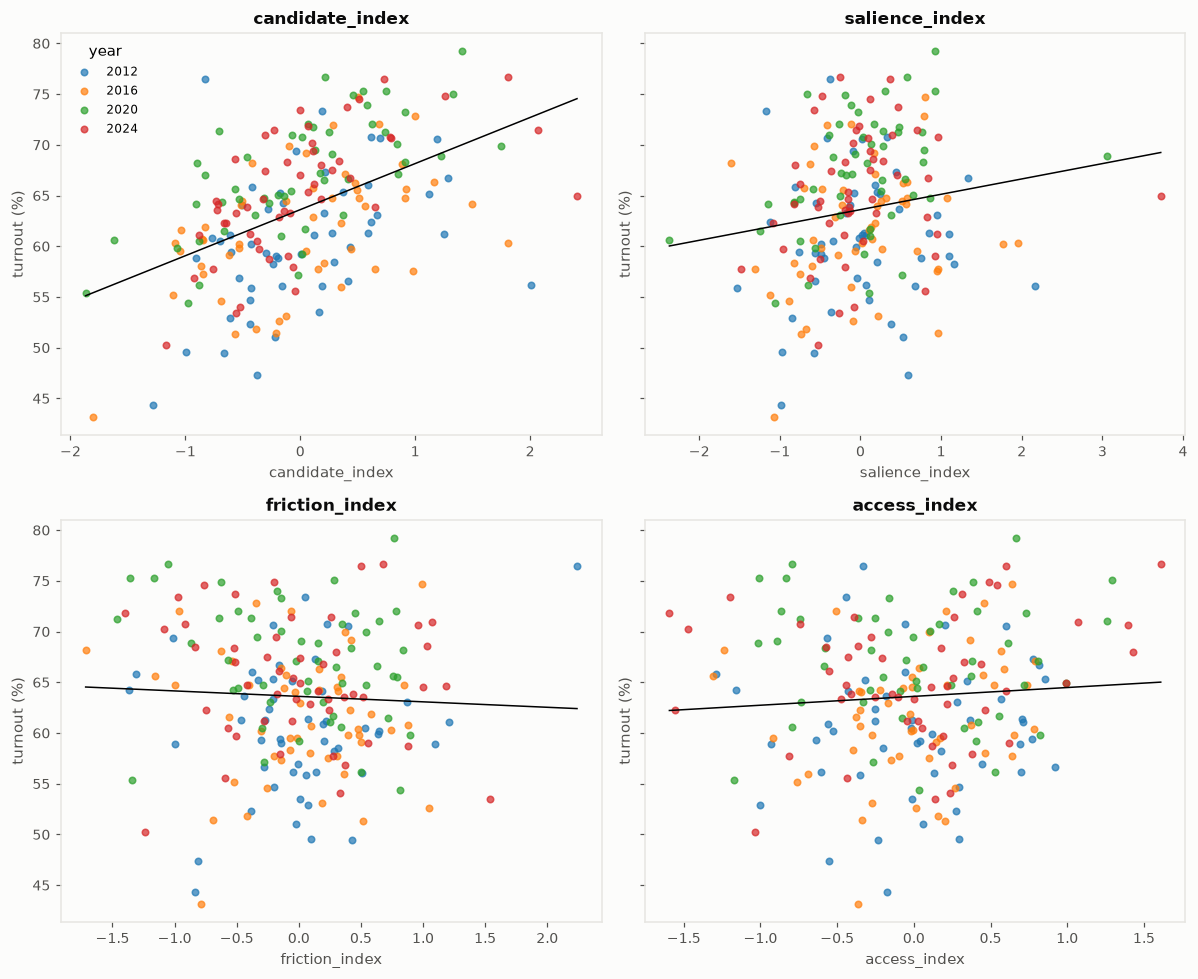

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
for ax, f in zip(axes.ravel(), TRENDS):
    for y, g in model_df.groupby("year"):
        ax.scatter(g[f], g.turnout, s=18, alpha=.7, label=str(y))
    b = np.polyfit(model_df[f], model_df.turnout, 1)
    xs = np.linspace(model_df[f].min(), model_df[f].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color="black", lw=1)
    ax.set_xlabel(f); ax.set_ylabel("turnout (%)"); ax.set_title(f)
axes[0, 0].legend(title="year", fontsize=8)
plt.tight_layout(); plt.show()

# 3. RQ1 - Can turnout be predicted from Google Trends?
Baseline and Google Trends OLS models, held out on 2024 and validated by forward chaining.

### 3.1
Defines the eight model specifications and scores all of them on the held-out 2024 election.

In [44]:
MODELS = {
    "B0  national mean":            [],
    "B1  turnout_prev":             ["turnout_prev"],
    "B2  + friction":               ["turnout_prev", "friction_index"],
    "B3  + salience":               ["turnout_prev", "salience_index"],
    "B4  + access":                 ["turnout_prev", "access_index"],
    "B5  + candidate":              ["turnout_prev", "candidate_index"],
    "B6  + all four":               FEATS,
    "B7  Trends only (no history)": TRENDS,
}
B1 = next(k for k in MODELS if k.startswith("B1"))      # baseline key (has 2 spaces)

def run_all(train_df, test_df, models=MODELS):
    """Fit each model on train_df, score on test_df. Returns (metrics, predictions)."""
    rows, preds = [], {}
    for name, cols in models.items():
        p = (np.full(len(test_df), train_df.turnout.mean()) if not cols
             else predict(fit_ols(train_df[cols].values, train_df.turnout.values),
                          test_df[cols].values))
        preds[name] = p
        rows.append(dict(model=name, k=len(cols), **scores(test_df.turnout.values, p)))

    res = pd.DataFrame(rows).set_index("model")
    res["dMAE"] = res.MAE - res.loc[B1, "MAE"]          # vs history-only baseline

    P = pd.DataFrame(preds)
    P.insert(0, "state",   test_df.state.values)
    P.insert(1, "turnout", test_df.turnout.values)
    return res, P

tr = model_df[model_df.year <  2024]
te = model_df[model_df.year == 2024]
res, P = run_all(tr, te)
print(f"train {sorted(tr.year.unique().tolist())} (n={len(tr)}) -> test 2024 (n={len(te)})\n")
print(res.round(3).to_string())

train [2012, 2016, 2020] (n=153) -> test 2024 (n=51)

                              k    MAE   RMSE     R2   dMAE
model                                                      
B0  national mean             0  5.150  6.420 -0.132  2.643
B1  turnout_prev              1  2.507  2.979  0.756  0.000
B2  + friction                2  2.511  3.031  0.748  0.004
B3  + salience                2  2.510  2.988  0.755  0.004
B4  + access                  2  2.516  2.994  0.754  0.010
B5  + candidate               2  2.152  2.618  0.812 -0.355
B6  + all four                5  2.240  2.748  0.793 -0.266
B7  Trends only (no history)  4  4.484  5.305  0.227  1.978


### 3.2
Bar charts of MAE, RMSE and R-squared for every model, against the history-only baseline.

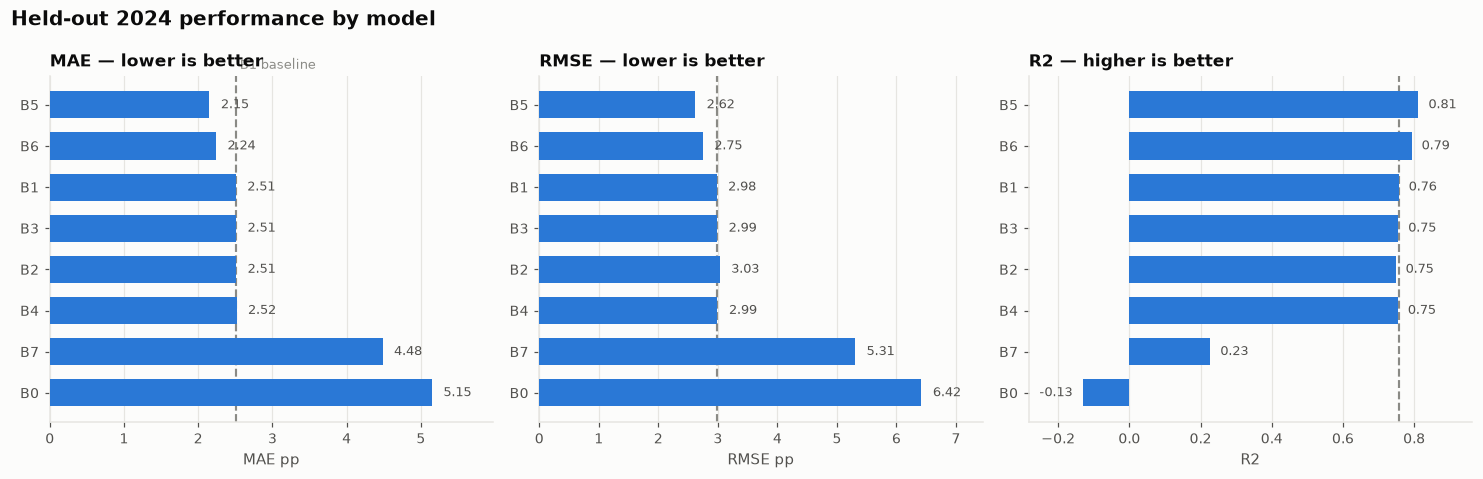

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
order = res.MAE.sort_values(ascending=False).index          # best model ends up on top

for ax, (metric, unit, better) in zip(axes, [("MAE", " pp", "lower"),
                                             ("RMSE", " pp", "lower"),
                                             ("R2", "", "higher")]):
    v = res.loc[order, metric]
    ax.barh(range(len(v)), v.values, height=0.66, color=BLUE, zorder=3)
    ax.axvline(res.loc[B1, metric], color=MUTED, ls="--", lw=1.4, zorder=2)   # baseline ref
    ax.set_yticks(range(len(v)), [s.split("  ")[0] for s in v.index])
    pad = (v.max() - min(v.min(), 0)) * 0.03
    for i, x in enumerate(v.values):
        ax.text(x + pad if x >= 0 else x - pad, i, f"{x:.2f}", va="center",
                ha="left" if x >= 0 else "right", fontsize=8.5, color=INK2)
    ax.set_title(f"{metric} — {better} is better", loc="left")
    ax.set_xlabel(metric + unit)
    ax.margins(x=0.16)
    clean(ax, grid_axis="x")

axes[0].text(res.loc[B1, "MAE"], len(order) - 0.2, " B1 baseline",
             fontsize=8.5, color=MUTED, va="bottom")
fig.suptitle("Held-out 2024 performance by model", x=0.005, ha="left",
             fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

### 3.3
Predicted-versus-actual scatter for each model, with the three worst-missed states labelled.

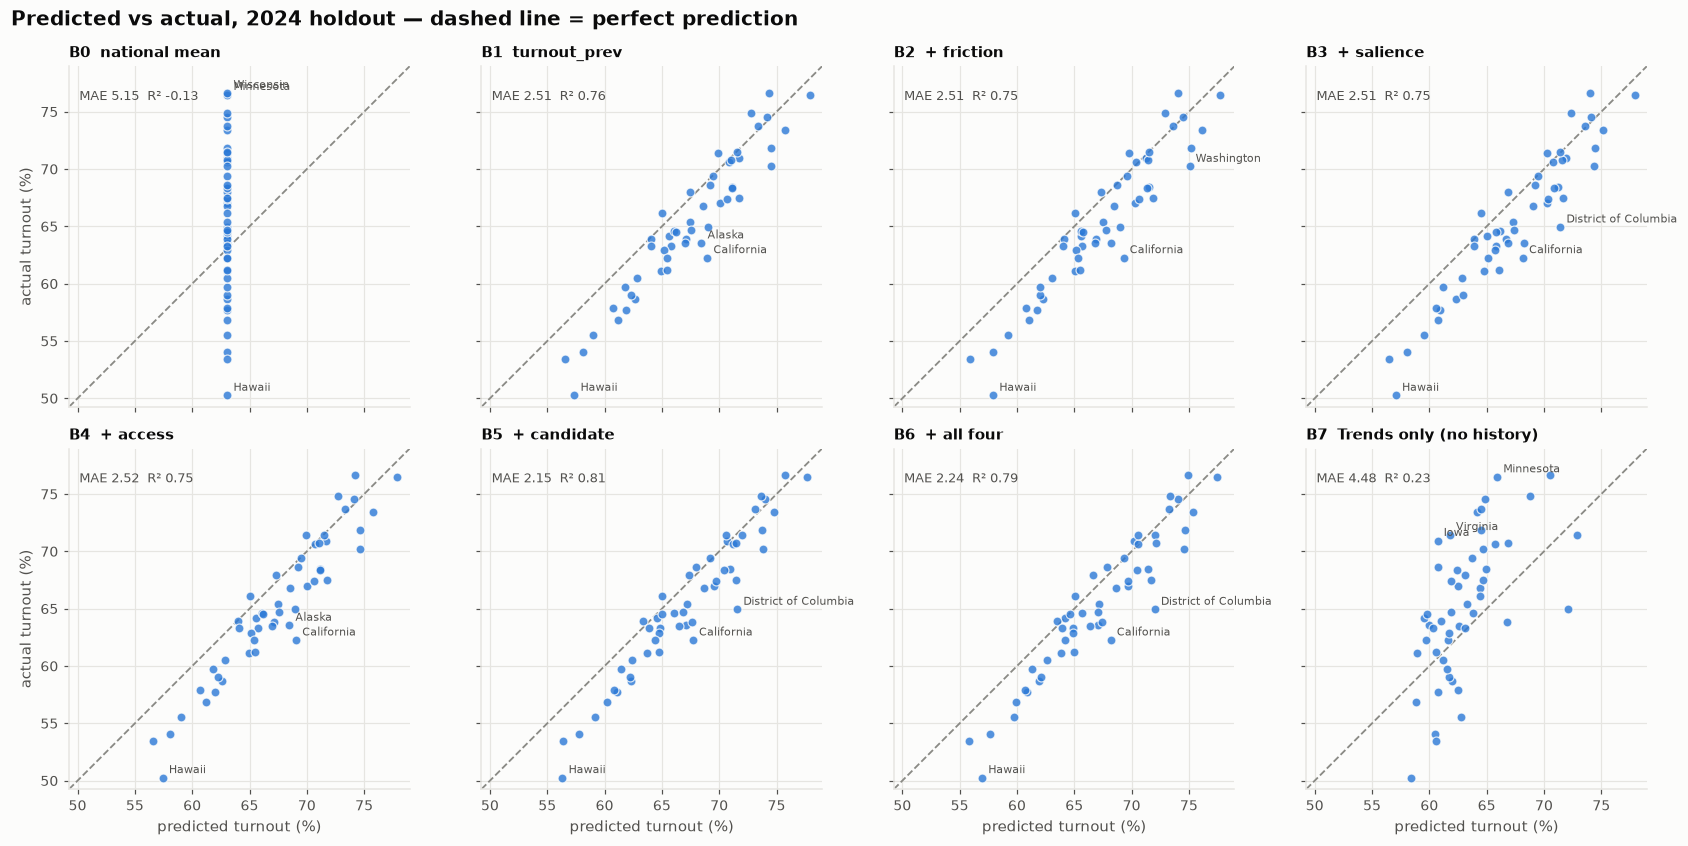

In [46]:
names = list(MODELS)
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.8), sharex=True, sharey=True)
lo = min(P.turnout.min(), P[names].values.min()) - 1
hi = max(P.turnout.max(), P[names].values.max()) + 1

for ax, name in zip(axes.ravel(), names):
    resid = P.turnout - P[name]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1.2, zorder=2)   # perfect fit
    ax.scatter(P[name], P.turnout, s=34, color=BLUE, alpha=.8,
               edgecolor=SURF, linewidth=.8, zorder=3)
    for i in resid.abs().nlargest(3).index:                                # label worst 3 only
        ax.annotate(P.state[i], (P[name][i], P.turnout[i]), fontsize=7.5,
                    color=INK2, xytext=(4, 3), textcoords="offset points")
    ax.set_title(name, loc="left", fontsize=10)
    ax.text(.03, .93, f"MAE {res.loc[name,'MAE']:.2f}  R² {res.loc[name,'R2']:.2f}",
            transform=ax.transAxes, fontsize=8.5, color=INK2, va="top")
    ax.set_aspect("equal"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    clean(ax, grid_axis="both")

for ax in axes[:, 0]: ax.set_ylabel("actual turnout (%)")
for ax in axes[-1, :]: ax.set_xlabel("predicted turnout (%)")
fig.suptitle("Predicted vs actual, 2024 holdout — dashed line = perfect prediction",
             x=0.005, ha="left", fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

### 3.4
Forward-chaining rolling validation across all three folds (test 2016, 2020 and 2024).

In [47]:
FOLDS = [([2012],             2016),
         ([2012, 2016],       2020),
         ([2012, 2016, 2020], 2024)]

cv = {}
for train_years, test_year in FOLDS:
    a = model_df[model_df.year.isin(train_years)]
    b = model_df[model_df.year == test_year]
    cv[f"test {test_year}"] = [
        scores(b.turnout.values,
               np.full(len(b), a.turnout.mean()) if not cols
               else predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values)
              )["MAE"]
        for cols in MODELS.values()]
cv = pd.DataFrame(cv, index=list(MODELS))
cv["mean"] = cv.mean(axis=1)

# the 2016 fold trains on 2012 alone (51 rows) - weakest fold by construction, reported for completeness
print("training rows per fold:",
      {t: len(model_df[model_df.year.isin(ty)]) for ty, t in FOLDS})
print("\nrolling-origin CV - MAE (pp):")
print(cv.round(3).to_string())

training rows per fold: {2016: 51, 2020: 102, 2024: 153}

rolling-origin CV - MAE (pp):
                              test 2016  test 2020  test 2024   mean
B0  national mean                 4.940      6.969      5.150  5.686
B1  turnout_prev                  4.703      6.412      2.507  4.540
B2  + friction                    4.679      6.412      2.511  4.534
B3  + salience                    4.677      6.410      2.510  4.533
B4  + access                      4.746      6.411      2.516  4.558
B5  + candidate                   4.537      6.386      2.152  4.358
B6  + all four                    4.604      6.386      2.240  4.410
B7  Trends only (no history)      5.268      6.413      4.484  5.388


### 3.5
Dot plot of each model's MAE in every fold.

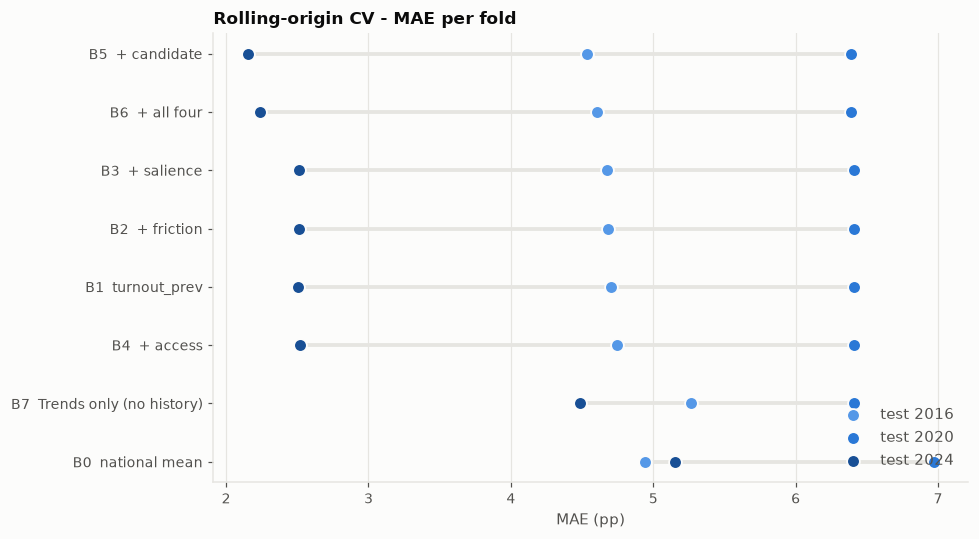

In [48]:
o     = cv["mean"].sort_values(ascending=False).index
folds = [c for c in cv.columns if c != "mean"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.hlines(range(len(o)), cv.loc[o, folds].min(axis=1), cv.loc[o, folds].max(axis=1),
          color=GRID, lw=2.5, zorder=2)
for f in folds:
    ax.scatter(cv.loc[o, f], range(len(o)), s=70, color=YEAR_RAMP[int(f.split()[-1])],
               label=f, edgecolor=SURF, lw=1.2, zorder=3)
ax.set_yticks(range(len(o)), o, fontsize=9)
ax.set_xlabel("MAE (pp)"); ax.legend(loc="lower right", labelcolor=INK2)
ax.set_title("Rolling-origin CV - MAE per fold", loc="left")
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()

### 3.6
Permutation importance of the OLS features, with a pure-noise column as the control.

baseline test MAE = 2.145 pp


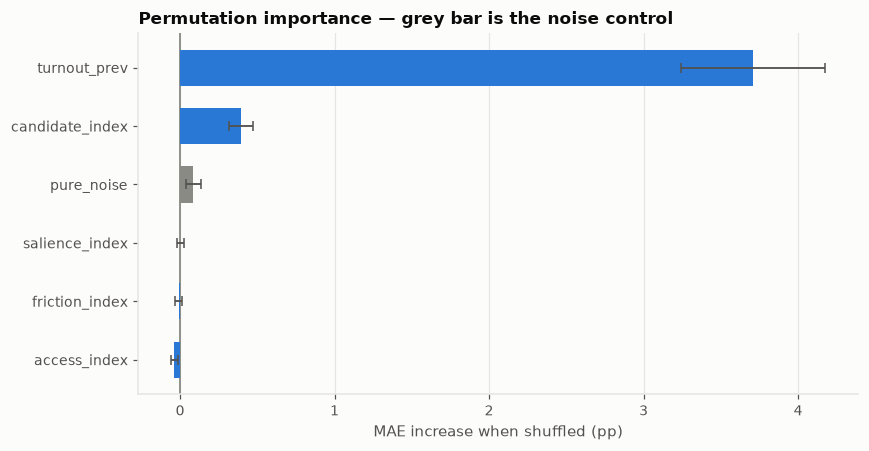

In [49]:
rng   = np.random.default_rng(0)
trp   = model_df[model_df.year <  2024].copy()
tep   = model_df[model_df.year == 2024].copy()
trp["pure_noise"] = rng.normal(size=len(trp))
tep["pure_noise"] = rng.normal(size=len(tep))
COLS  = FEATS + ["pure_noise"]

coef       = fit_ols(trp[COLS].values, trp.turnout.values)
X_te, y_te = tep[COLS].values, tep.turnout.values
base_mae   = np.abs(y_te - predict(coef, X_te)).mean()
print(f"baseline test MAE = {base_mae:.3f} pp")

rows = []
for i, f in enumerate(COLS):
    ds = []
    for _ in range(100):
        Xp = X_te.copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        ds.append(np.abs(y_te - predict(coef, Xp)).mean() - base_mae)
    rows.append(dict(feature=f, rise=np.mean(ds), sd=np.std(ds)))
imp = pd.DataFrame(rows).sort_values("rise")

fig, ax = plt.subplots(figsize=(8, 4.2))
cols_ = [MUTED if f == "pure_noise" else BLUE for f in imp.feature]
ax.barh(imp.feature, imp.rise, xerr=imp.sd, height=0.62, color=cols_,
        error_kw=dict(ecolor=INK2, lw=1.2, capsize=3), zorder=3)
ax.axvline(0, color=MUTED, lw=1.2, zorder=2)
ax.set_xlabel("MAE increase when shuffled (pp)")
ax.set_title("Permutation importance — grey bar is the noise control", loc="left")
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()

### 3.7
Compares the original, Topic-based and expanded candidate indices on the 2024 holdout and in rolling CV.

In [50]:
MODELS_C = {
    "B1  turnout_prev":          ["turnout_prev"],
    "B5  + cand v1 (current)":   ["turnout_prev", "cand_v1"],
    "B5t + cand v1 Topic":       ["turnout_prev", "cand_v1t"],
    "B5x + cand v2 expanded":    ["turnout_prev", "cand_v2"],
}

tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
res_c, P_c = run_all(tr, te, models=MODELS_C)

# de-biased MAE: strips the national level miss, leaves cross-state accuracy
e = P_c[list(MODELS_C)].rsub(P_c.turnout, axis=0)
res_c["bias"]        = e.mean()
res_c["debiased_MAE"] = (e - e.mean()).abs().mean()
print(res_c.round(3).to_string())

print(f"\n{'rolling CV MAE':<28}" + "".join(f"{'test '+str(t):>11}" for _, t in FOLDS))
for name, cols in MODELS_C.items():
    maes = []
    for ty, t in FOLDS:
        a, b_ = model_df[model_df.year.isin(ty)], model_df[model_df.year == t]
        maes.append(scores(b_.turnout.values,
                           predict(fit_ols(a[cols].values, a.turnout.values),
                                   b_[cols].values))["MAE"])
    print(f"{name:<28}" + "".join(f"{x:>11.3f}" for x in maes))

                         k    MAE   RMSE     R2   dMAE   bias  debiased_MAE
model                                                                      
B1  turnout_prev         1  2.507  2.979  0.756  0.000 -2.179         1.632
B5  + cand v1 (current)  2  2.152  2.618  0.812 -0.355 -1.852         1.486
B5t + cand v1 Topic      2  2.161  2.659  0.806 -0.345 -1.750         1.484
B5x + cand v2 expanded   2  2.120  2.555  0.821 -0.387 -1.706         1.467

rolling CV MAE                test 2016  test 2020  test 2024
B1  turnout_prev                  4.703      6.412      2.507
B5  + cand v1 (current)           4.537      6.386      2.152
B5t + cand v1 Topic               4.511      6.380      2.161
B5x + cand v2 expanded            4.464      6.374      2.120


### 3.8
Sensitivity check: does blanking running-mate home states change the result?

In [51]:
tr = model_df[model_df.year <  2024]
te = model_df[model_df.year == 2024]
r2, _ = run_all(tr, te, models={"B1  turnout_prev":      ["turnout_prev"],
                                "B5x + cand v2":         ["turnout_prev", "cand_v2"],
                                "B5h + cand v2 no-home": ["turnout_prev", "cand_v2_nohome"]})
print(r2.round(3).to_string())

                       k    MAE   RMSE     R2   dMAE
model                                               
B1  turnout_prev       1  2.507  2.979  0.756  0.000
B5x + cand v2          2  2.120  2.555  0.821 -0.387
B5h + cand v2 no-home  2  2.100  2.543  0.822 -0.406


### 3.9
Per-state residuals of the best model (B5x) on 2024 - where it misses and by how much.

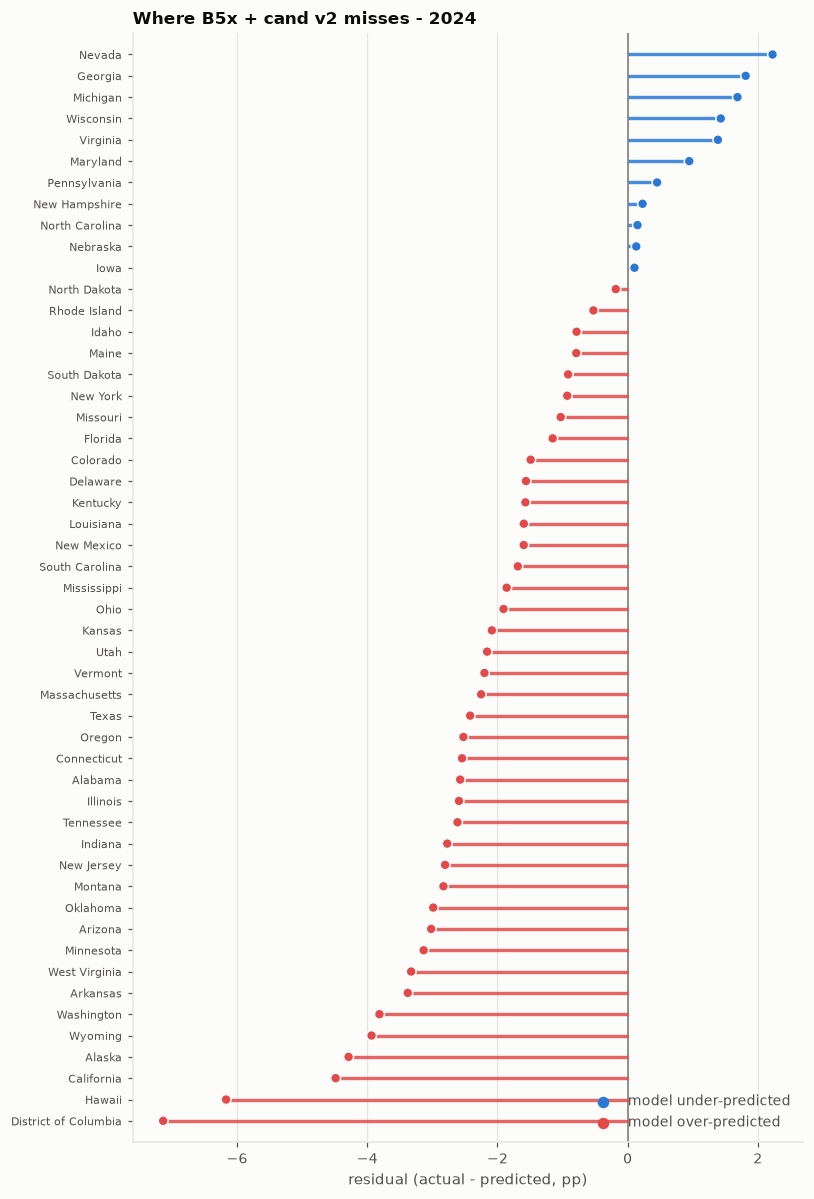

In [52]:
assert "cand_v2" in model_df, "run 1.8 first - cand_v2 is built there"

PICK   = "B5x + cand v2"
COLS_P = ["turnout_prev", "cand_v2"]
_tr = model_df[model_df.year <  2024]
_te = model_df[model_df.year == 2024]
_p  = predict(fit_ols(_tr[COLS_P].values, _tr.turnout.values), _te[COLS_P].values)
d   = (pd.DataFrame({"state": _te.state.values, "resid": _te.turnout.values - _p})
         .sort_values("resid"))
# identical fit to 3.7's B5x row - guards against the two drifting apart
assert np.allclose(np.sort(d.resid.values),
                   np.sort((P_c.turnout - P_c["B5x + cand v2 expanded"]).values))

fig, ax = plt.subplots(figsize=(7.5, 11))
colors = np.where(d.resid >= 0, BLUE, RED)
ax.hlines(range(len(d)), 0, d.resid, color=colors, lw=2.2, alpha=.85, zorder=3)
ax.scatter(d.resid, range(len(d)), s=42, color=colors,
           edgecolor=SURF, linewidth=1, zorder=4)
ax.axvline(0, color=MUTED, lw=1.2, zorder=2)
ax.set_yticks(range(len(d)), d.state, fontsize=7.5)
ax.set_ylim(-1, len(d)); ax.set_xlabel("residual (actual - predicted, pp)")
ax.set_title(f"Where {PICK} misses - 2024", loc="left")
ax.scatter([], [], s=42, color=BLUE, label="model under-predicted")
ax.scatter([], [], s=42, color=RED,  label="model over-predicted")
ax.legend(loc="lower right", fontsize=9, labelcolor=INK2)
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()

# 4. RQ2 - Does gradient boosting beat the baselines?
Gradient boosting on its own (4.1-4.5), then a hybrid that boosts the OLS residuals (4.6-4.11).

### 4.1
Gradient-boosting setup: feature sets, hyperparameter grid, fit/predict helpers and cached leave-one-year-out tuning.

In [53]:
# one-time: %pip install scikit-learn

from itertools import product
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# same feature sets for both methods -> any difference is the algorithm, not the inputs
GB_SETS = {
    "B1  turnout_prev": ["turnout_prev"],
    "B5x + cand v2":    ["turnout_prev", "cand_v2"],
    "B6  + all four":   FEATS,
}

# small, shallow grid - 150 training rows can't support big trees
GRID = [dict(max_depth=d, learning_rate=lr, max_iter=n, min_samples_leaf=leaf)
        for d, lr, n, leaf in product([2, 3], [0.03, 0.1], [100, 300], [10, 20])]

def fit_predict_gb(train_df, test_df, cols, params, target="level"):
    """target='level' predicts turnout; 'change' predicts turnout - turnout_prev, then adds it back."""
    shift_tr = train_df.turnout_prev.values if target == "change" else 0
    shift_te = test_df.turnout_prev.values  if target == "change" else 0
    mono = [1 if (c == "turnout_prev" and target == "level") else 0 for c in cols]
    m = HistGradientBoostingRegressor(**params, monotonic_cst=mono,
                                      early_stopping=False, random_state=0)
    m.fit(train_df[cols], train_df.turnout.values - shift_tr)
    return m.predict(test_df[cols]) + shift_te, m

def tune_gb(train_df, cols, target):
    """Leave-one-year-out inside the training years only - the test year is never seen."""
    years = sorted(train_df.year.unique())
    best, best_mae = None, np.inf
    for params in GRID:
        maes = []
        for y in years:
            a, b = train_df[train_df.year != y], train_df[train_df.year == y]
            p, _ = fit_predict_gb(a, b, cols, params, target)
            maes.append(np.abs(b.turnout.values - p).mean())
        if np.mean(maes) < best_mae:
            best, best_mae = params, np.mean(maes)
    return best

def full_scores(y, p):
    e = y - p                                   # actual - predicted, same sign as cell 39
    return dict(**scores(y, p), bias=e.mean(), debiased_MAE=np.abs(e - e.mean()).mean())


# --- cached tuning -----------------------------------------------------------
# The 2024 rolling-CV fold trains on exactly the same years as the 4.2 holdout,
# so without this the identical grid search runs twice. Cache is per-kernel.
GB_DEFAULT = dict(max_depth=2, learning_rate=0.03, max_iter=100, min_samples_leaf=20)
_TUNE_GB = {}

def tune_gb_cached(train_df, cols, target):
    """Memoised tune_gb. LOYO needs >=2 training years; the 2016 fold trains on 2012 alone."""
    key = (tuple(sorted(train_df.year.unique())), tuple(cols), target)
    if key not in _TUNE_GB:
        _TUNE_GB[key] = (tune_gb(train_df, cols, target)
                         if train_df.year.nunique() >= 2 else GB_DEFAULT)
    return _TUNE_GB[key]

### 4.2
OLS versus gradient boosting on the 2024 holdout, across three feature sets and two prediction targets.

In [54]:
tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
y_te = te.turnout.values

rows, preds, gb_models = [], {}, {}
for name, cols in GB_SETS.items():
    p = predict(fit_ols(tr[cols].values, tr.turnout.values), te[cols].values)
    preds[("OLS", name)] = p
    rows.append(dict(features=name, method="OLS", **full_scores(y_te, p)))
    for target in ["level", "change"]:
        params = tune_gb_cached(tr, cols, target)
        p, m = fit_predict_gb(tr, te, cols, params, target)
        preds[(f"GB-{target}", name)] = p
        gb_models[(f"GB-{target}", name)] = m
        rows.append(dict(features=name, method=f"GB-{target}", **full_scores(y_te, p),
                         depth=params["max_depth"], lr=params["learning_rate"],
                         trees=params["max_iter"], leaf=params["min_samples_leaf"]))

cmp = pd.DataFrame(rows)
_ols = cmp[cmp.method == "OLS"].set_index("features").MAE      # explicit, not row-order
cmp.insert(2, "dMAE_vs_OLS", cmp.MAE - cmp.features.map(_ols))
print(f"train 2012–2020 (n={len(tr)}) -> test 2024 (n={len(te)})\n")
print(cmp.round(3).to_string(index=False))

train 2012–2020 (n=153) -> test 2024 (n=51)

        features    method  dMAE_vs_OLS   MAE  RMSE    R2   bias  debiased_MAE  depth   lr  trees  leaf
B1  turnout_prev       OLS        0.000 2.507 2.979 0.756 -2.179         1.632    NaN  NaN    NaN   NaN
B1  turnout_prev  GB-level        0.247 2.753 3.267 0.707 -2.138         1.963    2.0 0.03  100.0  10.0
B1  turnout_prev GB-change        0.133 2.639 3.129 0.731 -2.333         1.683    2.0 0.03  100.0  20.0
   B5x + cand v2       OLS        0.000 2.120 2.555 0.821 -1.706         1.467    NaN  NaN    NaN   NaN
   B5x + cand v2  GB-level        0.092 2.212 2.719 0.797 -1.225         1.826    2.0 0.03  100.0  10.0
   B5x + cand v2 GB-change        0.189 2.309 2.763 0.790 -1.862         1.556    2.0 0.03  100.0  20.0
  B6  + all four       OLS        0.000 2.240 2.748 0.793 -1.864         1.605    NaN  NaN    NaN   NaN
  B6  + all four  GB-level        0.182 2.422 3.001 0.753 -1.495         2.097    2.0 0.03  100.0  10.0
  B6  + all four GB

### 4.3
The same comparison run across all three rolling-validation folds.

In [55]:
cv_rows = []
for train_years, test_year in FOLDS:
    a = model_df[model_df.year.isin(train_years)]
    b = model_df[model_df.year == test_year]
    for name, cols in GB_SETS.items():
        p = predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values)
        cv_rows.append(dict(features=name, method="OLS", test=test_year,
                            MAE=np.abs(b.turnout.values - p).mean()))
        for target in ["level", "change"]:
            p, _ = fit_predict_gb(a, b, cols, tune_gb_cached(a, cols, target), target)
            cv_rows.append(dict(features=name, method=f"GB-{target}", test=test_year,
                                MAE=np.abs(b.turnout.values - p).mean()))

cv_gb = (pd.DataFrame(cv_rows)
           .pivot_table(index=["features", "method"], columns="test", values="MAE", sort=False))
cv_gb["mean"] = cv_gb.mean(axis=1)
print(cv_gb.round(3).to_string())

test                         2016   2020   2024   mean
features         method                               
B1  turnout_prev OLS        4.703  6.412  2.507  4.540
                 GB-level   4.819  6.360  2.753  4.644
                 GB-change  4.597  6.616  2.639  4.617
B5x + cand v2    OLS        4.464  6.374  2.120  4.319
                 GB-level   4.302  6.382  2.212  4.299
                 GB-change  4.366  6.311  2.309  4.329
B6  + all four   OLS        4.604  6.386  2.240  4.410
                 GB-level   4.629  6.279  2.422  4.443
                 GB-change  4.370  6.110  2.447  4.309


### 4.4
Bootstrap test of whether gradient boosting's difference from OLS is real or sampling noise.

In [56]:
SET, GB = "B5x + cand v2", "GB-change"          # change these to test other pairs
d = np.abs(y_te - preds[(GB, SET)]) - np.abs(y_te - preds[("OLS", SET)])
rng_b = np.random.default_rng(0)
boot = np.array([rng_b.choice(d, len(d)).mean() for _ in range(5000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"{GB} minus OLS on '{SET.strip()}': dMAE = {d.mean():+.3f} pp  "
      f"95% CI [{lo:+.3f}, {hi:+.3f}]  GB wins in {(boot < 0).mean():.0%} of resamples")

GB-change minus OLS on 'B5x + cand v2': dMAE = +0.189 pp  95% CI [-0.046, +0.424]  GB wins in 6% of resamples


### 4.5
Permutation importance of the gradient-boosting model's features.

In [57]:
KEY  = ("GB-change", "B6  + all four")
cols = GB_SETS[KEY[1]]
pi = permutation_importance(gb_models[KEY], te[cols], y_te - te.turnout_prev.values,
                            scoring="neg_mean_absolute_error", n_repeats=100, random_state=0)
print(pd.DataFrame({"MAE rise": pi.importances_mean, "sd": pi.importances_std}, index=cols)
        .sort_values("MAE rise", ascending=False).round(3).to_string())

                 MAE rise     sd
candidate_index     0.152  0.092
salience_index      0.137  0.064
access_index        0.131  0.082
turnout_prev       -0.027  0.077
friction_index     -0.043  0.032


### 4.6
Hybrid setup: fit OLS first, then let gradient boosting learn what OLS got wrong.

In [58]:
# smaller grid than Section 4: stumps allowed, L2 penalty, MAE loss
GRID_H = [dict(max_depth=d, learning_rate=0.03, max_iter=n, min_samples_leaf=leaf,
               l2_regularization=l2, loss="absolute_error")
          for d, n, leaf, l2 in product([1, 2], [50, 100, 200], [15, 25], [0.0, 1.0])]

def fit_predict_hyb(train_df, test_df, cols, params):
    """Step 1: OLS on cols. Step 2: GB learns what OLS got wrong. Prediction = OLS + GB."""
    b = fit_ols(train_df[cols].values, train_df.turnout.values)
    base_tr = predict(b, train_df[cols].values)
    base_te = predict(b, test_df[cols].values)
    m = HistGradientBoostingRegressor(**params, early_stopping=False, random_state=0)
    m.fit(train_df[cols], train_df.turnout.values - base_tr)
    corr = m.predict(test_df[cols])
    return base_te + corr, dict(ols=b, gb=m, base=base_te, corr=corr)

def tune_hyb(train_df, cols):
    """Leave-one-year-out inside training years, scored on de-biased MAE."""
    years = sorted(train_df.year.unique())
    best, best_mae = None, np.inf
    for params in GRID_H:
        maes = []
        for y in years:
            a, b = train_df[train_df.year != y], train_df[train_df.year == y]
            p, _ = fit_predict_hyb(a, b, cols, params)
            e = b.turnout.values - p
            maes.append(np.abs(e - e.mean()).mean())
        if np.mean(maes) < best_mae:
            best, best_mae = params, np.mean(maes)
    return best


HYB_DEFAULT = dict(max_depth=1, learning_rate=0.03, max_iter=50, min_samples_leaf=15,
                   l2_regularization=0.0, loss="absolute_error")
_TUNE_H = {}

def tune_hyb_cached(train_df, cols):
    """Memoised tune_hyb — same reason as tune_gb_cached in 4.1."""
    key = (tuple(sorted(train_df.year.unique())), tuple(cols))
    if key not in _TUNE_H:
        _TUNE_H[key] = (tune_hyb(train_df, cols)
                        if train_df.year.nunique() >= 2 else HYB_DEFAULT)
    return _TUNE_H[key]

### 4.7
OLS versus the hybrid on the 2024 holdout, reporting both raw and de-biased MAE.

In [59]:
tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
y_te = te.turnout.values

rows_h, preds_h, fits_h = [], {}, {}
for name, cols in GB_SETS.items():
    p_ols = predict(fit_ols(tr[cols].values, tr.turnout.values), te[cols].values)
    params = tune_hyb_cached(tr, cols)
    p_h, fit = fit_predict_hyb(tr, te, cols, params)
    preds_h[("OLS", name)], preds_h[("Hybrid", name)] = p_ols, p_h
    fits_h[name] = (params, fit)
    rows_h.append(dict(features=name, method="OLS", **full_scores(y_te, p_ols)))
    rows_h.append(dict(features=name, method="Hybrid", **full_scores(y_te, p_h),
                       avg_correction=np.abs(fit["corr"]).mean(),
                       depth=params["max_depth"], trees=params["max_iter"],
                       leaf=params["min_samples_leaf"], l2=params["l2_regularization"]))

cmp_h = pd.DataFrame(rows_h)
_o = cmp_h[cmp_h.method == "OLS"].set_index("features")        # explicit, not row-order
cmp_h.insert(2, "dMAE_vs_OLS",      cmp_h.MAE - cmp_h.features.map(_o.MAE))
cmp_h.insert(3, "dDebiased_vs_OLS", cmp_h.debiased_MAE - cmp_h.features.map(_o.debiased_MAE))
print(f"train 2012–2020 (n={len(tr)}) -> test 2024 (n={len(te)})\n")
print(cmp_h.round(3).to_string(index=False))

train 2012–2020 (n=153) -> test 2024 (n=51)

        features method  dMAE_vs_OLS  dDebiased_vs_OLS   MAE  RMSE    R2   bias  debiased_MAE  avg_correction  depth  trees  leaf  l2
B1  turnout_prev    OLS        0.000             0.000 2.507 2.979 0.756 -2.179         1.632             NaN    NaN    NaN   NaN NaN
B1  turnout_prev Hybrid       -0.165             0.060 2.342 2.802 0.784 -1.868         1.692           0.311    1.0   50.0  15.0 0.0
   B5x + cand v2    OLS        0.000             0.000 2.120 2.555 0.821 -1.706         1.467             NaN    NaN    NaN   NaN NaN
   B5x + cand v2 Hybrid       -0.132             0.024 1.988 2.458 0.834 -1.510         1.491           0.310    1.0   50.0  15.0 0.0
  B6  + all four    OLS        0.000             0.000 2.240 2.748 0.793 -1.864         1.605             NaN    NaN    NaN   NaN NaN
  B6  + all four Hybrid       -0.048            -0.063 2.193 2.678 0.803 -1.781         1.542           0.319    2.0   50.0  25.0 0.0


### 4.8
The same hybrid comparison across all three rolling-validation folds.

In [60]:
cv_rows_h = []
for train_years, test_year in FOLDS:
    a = model_df[model_df.year.isin(train_years)]
    b = model_df[model_df.year == test_year]
    for name, cols in GB_SETS.items():
        p_ols = predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values)
        p_h, _ = fit_predict_hyb(a, b, cols, tune_hyb_cached(a, cols))
        for meth, p in [("OLS", p_ols), ("Hybrid", p_h)]:
            e = b.turnout.values - p
            cv_rows_h.append(dict(features=name, method=meth, test=test_year,
                                  MAE=np.abs(e).mean(),
                                  debiased_MAE=np.abs(e - e.mean()).mean()))

cv_h = (pd.DataFrame(cv_rows_h)
          .pivot_table(index=["features", "method"], columns="test",
                       values=["MAE", "debiased_MAE"], sort=False))
print(cv_h.round(3).to_string())

                           MAE               debiased_MAE              
test                      2016   2020   2024         2016   2020   2024
features         method                                                
B1  turnout_prev OLS     4.703  6.412  2.507        1.792  1.831  1.632
                 Hybrid  4.732  5.848  2.342        1.806  1.892  1.692
B5x + cand v2    OLS     4.464  6.374  2.120        1.664  1.781  1.467
                 Hybrid  4.454  5.971  1.988        1.672  1.866  1.491
B6  + all four   OLS     4.604  6.386  2.240        1.785  1.905  1.605
                 Hybrid  4.382  5.844  2.193        1.772  1.850  1.542


### 4.9
Bootstrap test of the hybrid's improvement over OLS.

In [61]:
SET_H = "B5x + cand v2"
d_h = np.abs(y_te - preds_h[("Hybrid", SET_H)]) - np.abs(y_te - preds_h[("OLS", SET_H)])
rng_h = np.random.default_rng(0)
boot_h = np.array([rng_h.choice(d_h, len(d_h)).mean() for _ in range(5000)])
lo_h, hi_h = np.percentile(boot_h, [2.5, 97.5])
print(f"Hybrid minus OLS on '{SET_H.strip()}': dMAE = {d_h.mean():+.3f} pp  "
      f"95% CI [{lo_h:+.3f}, {hi_h:+.3f}]  Hybrid wins in {(boot_h < 0).mean():.0%} of resamples")

Hybrid minus OLS on 'B5x + cand v2': dMAE = -0.132 pp  95% CI [-0.213, -0.046]  Hybrid wins in 100% of resamples


### 4.10
Permutation importance of the hybrid, with a pure-noise control.

In [62]:
IMP_H = "B6  + all four"
params_i = fits_h[IMP_H][0]
rng_i = np.random.default_rng(0)
trn = model_df[model_df.year < 2024].copy();  trn["pure_noise"] = rng_i.normal(size=len(trn))
ten = model_df[model_df.year == 2024].copy(); ten["pure_noise"] = rng_i.normal(size=len(ten))
COLS_H = GB_SETS[IMP_H] + ["pure_noise"]
_, fit_i = fit_predict_hyb(trn, ten, COLS_H, params_i)

def hyb_predict(X):
    return predict(fit_i["ols"], X.values) + fit_i["gb"].predict(X)

base = np.abs(ten.turnout.values - hyb_predict(ten[COLS_H])).mean()
imp_rows = []
for c in COLS_H:
    ds = []
    for _ in range(100):
        Xp = ten[COLS_H].copy()
        Xp[c] = rng_i.permutation(Xp[c].values)
        ds.append(np.abs(ten.turnout.values - hyb_predict(Xp)).mean() - base)
    imp_rows.append(dict(feature=c, rise=np.mean(ds), sd=np.std(ds)))
imp_h = pd.DataFrame(imp_rows).set_index("feature").sort_values("rise", ascending=False)
print(f"baseline hybrid MAE = {base:.3f} pp\n")
print(imp_h.round(3).to_string())

baseline hybrid MAE = 2.092 pp

                  rise     sd
feature                      
turnout_prev     3.598  0.460
candidate_index  0.445  0.091
pure_noise       0.069  0.052
access_index    -0.015  0.023
salience_index  -0.021  0.032
friction_index  -0.057  0.041


### 4.11
Charts: de-biased MAE by method, and the per-state correction gradient boosting adds to OLS.

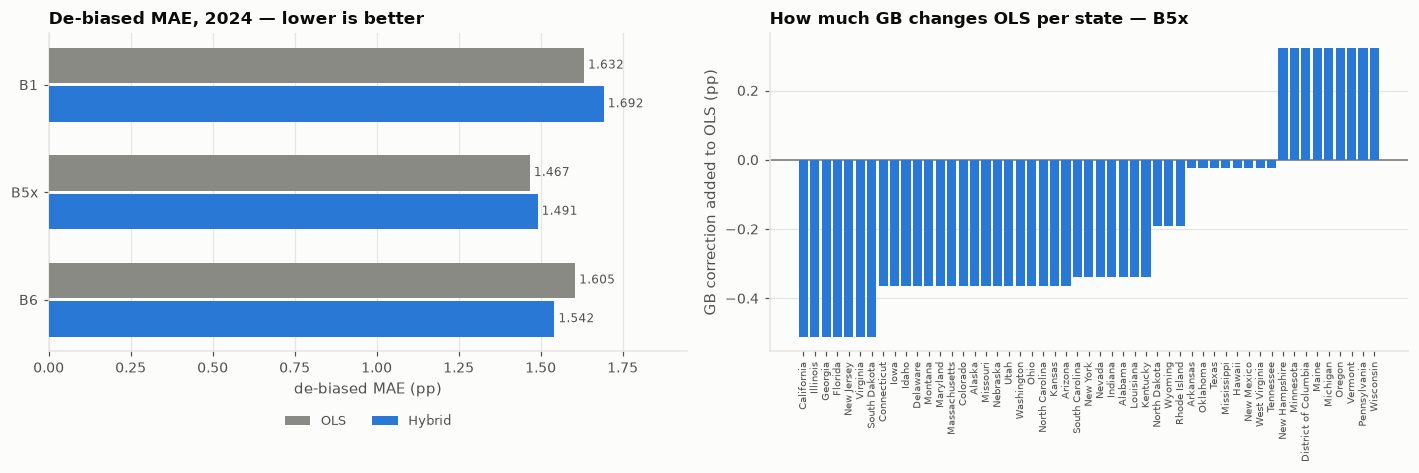

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
SETS_ORD = list(GB_SETS)
short = lambda s: s.split("  ")[0].split(" +")[0]
h = 0.36
for j, (meth, col) in enumerate([("OLS", MUTED), ("Hybrid", BLUE)]):
    v = cmp_h[cmp_h.method == meth].set_index("features").loc[SETS_ORD, "debiased_MAE"]
    ys = np.arange(len(SETS_ORD)) + (j - 0.5) * h
    ax.barh(ys, v.values, height=h * 0.92, color=col, label=meth, zorder=3)
    for y, x in zip(ys, v.values):
        ax.text(x, y, f" {x:.3f}", va="center", ha="left", fontsize=8, color=INK2)
ax.set_yticks(range(len(SETS_ORD)), [short(s) for s in SETS_ORD]); ax.invert_yaxis()
ax.set_xlabel("de-biased MAE (pp)"); ax.margins(x=0.15)
ax.set_title("De-biased MAE, 2024 — lower is better", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8.5, labelcolor=INK2)
clean(ax, grid_axis="x")

ax = axes[1]
fit_b = fits_h[SET_H][1]
order_s = np.argsort(fit_b["corr"])
ax.axhline(0, color=MUTED, lw=1.2, zorder=2)
ax.bar(range(len(order_s)), fit_b["corr"][order_s], color=BLUE, width=0.8, zorder=3)
ax.set_xticks(range(len(order_s)), te.state.values[order_s], rotation=90, fontsize=6.5)
ax.set_ylabel("GB correction added to OLS (pp)")
ax.set_title(f"How much GB changes OLS per state — {short(SET_H)}", loc="left")
clean(ax, grid_axis="y")
plt.tight_layout(); plt.show()

# 5. RQ3 - Which factors matter, and do regions differ?

### 5.1
Adds Census region, previous-election margin and a battleground flag to the panel.

In [64]:
ABBR = {
 "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO",
 "Connecticut":"CT","Delaware":"DE","District of Columbia":"DC","Florida":"FL","Georgia":"GA",
 "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
 "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA",
 "Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT",
 "Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM",
 "New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
 "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
 "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
 "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"}

REGION = {**{s: "Northeast" for s in ["CT","ME","MA","NH","RI","VT","NJ","NY","PA"]},
          **{s: "Midwest"   for s in ["IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"]},
          **{s: "South"     for s in ["DE","DC","FL","GA","MD","NC","SC","VA","WV","AL","KY",
                                      "MS","TN","AR","LA","OK","TX"]},
          **{s: "West"      for s in ["AZ","CO","ID","MT","NV","NM","UT","WY","AK","CA","HI",
                                      "OR","WA"]}}
assert len(ABBR) == 51 and set(REGION) == set(ABBR.values())

# MIT Election Lab "U.S. President 1976–2020" file (1976-2024-president.csv)
PRES_VOTES = BASE / "Official Turnout Data" / "1976-2024-president.csv"

v = pd.read_csv(PRES_VOTES)
v = v[v.year.between(2008, 2020)]
v["state"] = v.state.str.title().str.replace(" Of ", " of ")
two = (v[v.party_simplified.isin(["DEMOCRAT", "REPUBLICAN"])]
         .groupby(["state", "year", "party_simplified"]).candidatevotes.sum()
         .unstack())
margin = (100 * (two.DEMOCRAT - two.REPUBLICAN).abs() / two.sum(axis=1)).rename("margin")
margin = margin.reset_index()
margin["year"] = margin.year + 4          # 2008 margin -> used for the 2012 row, etc.
margin = margin.rename(columns={"margin": "margin_prev"})

model_df = (model_df.drop(columns=["margin_prev", "abbr", "region", "battleground"], errors="ignore")
                    .merge(margin, on=["state", "year"], how="left"))
model_df["abbr"]   = model_df.state.map(ABBR)
model_df["region"] = model_df.abbr.map(REGION)
model_df["battleground"] = (model_df.margin_prev < 5).astype(int)

assert model_df[["margin_prev", "region"]].notna().all().all(), "unmatched state names"
print(model_df.groupby("year").battleground.sum().rename("battleground states").to_string())
print("\nr(cand_v2, margin_prev) =", round(model_df.cand_v2.corr(model_df.margin_prev), 3))

year
2012     6
2016     4
2020    10
2024     8

r(cand_v2, margin_prev) = 0.099


### 5.2
Standardised OLS coefficients - factor ranking by effect size per standard deviation.

In [65]:
def ols_table(df, cols, target="turnout"):
    """OLS on standardised predictors: coef = pp turnout per 1 SD of the feature."""
    X = (df[cols] - df[cols].mean()) / df[cols].std()
    X = np.column_stack([np.ones(len(X)), X.values])
    y = df[target].values
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ b
    s2 = resid @ resid / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    return pd.DataFrame({"coef": b, "se": se, "lo95": b - 1.96 * se, "hi95": b + 1.96 * se,
                         "t": b / se}, index=["const"] + cols).drop("const")

ALL_F = ["turnout_prev", "cand_v2", "salience_index", "friction_index", "access_index", "margin_prev"]
tr = model_df[model_df.year < 2024]
coefs = ols_table(tr, ALL_F).sort_values("t", key=abs, ascending=False)
print(coefs.round(3).to_string())

                 coef     se   lo95   hi95       t
turnout_prev    4.560  0.438  3.702  5.419  10.412
cand_v2         1.525  0.551  0.445  2.604   2.768
margin_prev    -0.432  0.375 -1.167  0.302  -1.154
access_index   -0.198  0.376 -0.935  0.539  -0.527
salience_index -0.234  0.471 -1.157  0.688  -0.498
friction_index -0.090  0.373 -0.822  0.642  -0.241


### 5.3
Drop-one ablation - factor ranking by how much out-of-sample accuracy each feature actually buys.

In [66]:
def score_pair(train_df, test_df, cols):
    p = predict(fit_ols(train_df[cols].values, train_df.turnout.values), test_df[cols].values)
    e = test_df.turnout.values - p
    return np.abs(e).mean(), np.abs(e - e.mean()).mean()

abl = []
for train_years, test_year in FOLDS[-2:]:      # 2016 fold trains on 51 rows, too thin to rank 6 factors
    a = model_df[model_df.year.isin(train_years)]
    b = model_df[model_df.year == test_year]
    full_mae, full_db = score_pair(a, b, ALL_F)
    for f in ALL_F:
        keep = [c for c in ALL_F if c != f]
        mae, db = score_pair(a, b, keep)
        abl.append(dict(dropped=f, test=test_year,
                        dMAE=mae - full_mae, dDebiased=db - full_db))

abl = (pd.DataFrame(abl)
         .pivot_table(index="dropped", columns="test", values=["dMAE", "dDebiased"]))
abl["mean_dDebiased"] = abl["dDebiased"].mean(axis=1)
print("positive = dropping it HURTS = it matters\n")
print(abl.sort_values("mean_dDebiased", ascending=False).round(3).to_string())

positive = dropping it HURTS = it matters

               dDebiased          dMAE        mean_dDebiased
test                2020   2024   2020   2024               
dropped                                                     
turnout_prev       1.268  1.275 -0.127  1.429          1.271
cand_v2           -0.037  0.204  0.038  0.434          0.083
margin_prev        0.047  0.087 -0.033  0.177          0.067
friction_index    -0.014 -0.002  0.001 -0.006         -0.008
salience_index    -0.042 -0.003  0.013  0.039         -0.023
access_index       0.009 -0.075  0.001 -0.044         -0.033


### 5.4
Tests whether the candidate index survives once electoral competitiveness is controlled for.

In [67]:
te = model_df[model_df.year == 2024]
specs = {"B5x":             ["turnout_prev", "cand_v2"],
         "B5x + margin":    ["turnout_prev", "cand_v2", "margin_prev"],
         "B1 + margin":     ["turnout_prev", "margin_prev"]}
rows = []
for name, cols in specs.items():
    mae, db = score_pair(tr, te, cols)
    c = ols_table(tr, cols)
    rows.append(dict(model=name, MAE=mae, debiased_MAE=db,
                     cand_coef=c.coef.get("cand_v2", np.nan), cand_t=c.t.get("cand_v2", np.nan),
                     margin_coef=c.coef.get("margin_prev", np.nan)))
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

                MAE  debiased_MAE  cand_coef  cand_t  margin_coef
model                                                            
B5x           2.120         1.467      1.143   3.027          NaN
B5x + margin  1.906         1.376      1.312   3.287       -0.466
B1 + margin   2.476         1.618        NaN     NaN       -0.073


### 5.5
De-biased error broken down by Census region and by battleground status.

In [68]:
oos = []
for train_years, test_year in FOLDS[-2:]:      # keep the subgroup analysis on 2020 + 2024
    a = model_df[model_df.year.isin(train_years)]
    b = model_df[model_df.year == test_year].copy()
    for name, cols in {"B1": ["turnout_prev"], "B5x": ["turnout_prev", "cand_v2"]}.items():
        b[name] = predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values)
    oos.append(b)
oos = pd.concat(oos, ignore_index=True)
for m in ["B1", "B5x"]:
    e = oos.turnout - oos[m]
    oos[f"err_{m}"] = (e - e.groupby(oos.year).transform("mean")).abs()   # de-biased per year

def by_group(col):
    g = oos.groupby(col).agg(n=("state", "size"),
                             B1=("err_B1", "mean"), B5x=("err_B5x", "mean"))
    g["gain_from_cand"] = g.B1 - g.B5x
    return g.round(3)

print("de-biased MAE by region (test 2020 + 2024 pooled):")
print(by_group("region").to_string())
print("\nby battleground status (prev margin < 5pp):")
print(by_group("battleground").to_string())

de-biased MAE by region (test 2020 + 2024 pooled):
            n     B1    B5x  gain_from_cand
region                                     
Midwest    24  1.554  1.438           0.116
Northeast  18  1.602  1.407           0.195
South      34  1.634  1.581           0.053
West       26  2.113  2.002           0.111

by battleground status (prev margin < 5pp):
               n     B1    B5x  gain_from_cand
battleground                                  
0             84  1.647  1.507           0.140
1             18  2.125  2.170          -0.045


### 5.6
Interaction models testing whether the candidate effect differs by group.

In [69]:
pan = model_df.copy()
for c in ["cand_v2", "turnout_prev", "margin_prev"]:
    pan[c + "_z"] = (pan[c] - pan[c].mean()) / pan[c].std()
yr = pd.get_dummies(pan.year, prefix="y", drop_first=True, dtype=float)
rg = pd.get_dummies(pan.region, prefix="r", drop_first=True, dtype=float)   # Midwest = reference
pan = pd.concat([pan, yr, rg], axis=1)

def ols_inf(df, cols, target="turnout"):
    X = np.column_stack([np.ones(len(df)), df[cols].values.astype(float)])
    y = df[target].values
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    r = y - X @ b
    se = np.sqrt(np.diag(r @ r / (len(y) - X.shape[1]) * np.linalg.inv(X.T @ X)))
    return pd.DataFrame({"coef": b, "se": se, "t": b / se}, index=["const"] + cols)

base = ["turnout_prev_z", "cand_v2_z"] + list(yr.columns)

pan["cand_x_bg"] = pan.cand_v2_z * pan.battleground
m1 = ols_inf(pan, base + ["battleground", "cand_x_bg"])
print("A) does the candidate effect differ in battleground states?")
print(m1.loc[["cand_v2_z", "battleground", "cand_x_bg"]].round(3).to_string())

inter = []
for r in rg.columns:
    pan[f"cand_x_{r}"] = pan.cand_v2_z * pan[r]
    inter.append(f"cand_x_{r}")
m2 = ols_inf(pan, base + list(rg.columns) + inter)
print("\nB) does the candidate effect differ by region? (reference = Midwest)")
print(m2.loc[["cand_v2_z"] + list(rg.columns) + inter].round(3).to_string())

A) does the candidate effect differ in battleground states?
               coef     se      t
cand_v2_z     0.881  0.177  4.983
battleground  0.987  0.452  2.184
cand_x_bg    -0.711  0.448 -1.587

B) does the candidate effect differ by region? (reference = Midwest)
                     coef     se      t
cand_v2_z           1.089  0.404  2.698
r_Northeast        -0.044  0.515 -0.085
r_South            -0.007  0.418 -0.016
r_West              0.128  0.421  0.305
cand_x_r_Northeast -0.068  0.556 -0.123
cand_x_r_South     -0.487  0.452 -1.078
cand_x_r_West      -0.016  0.507 -0.031


### 5.7
Tile map of the 2024 residuals, showing the geographic pattern of the misses.

findfont: Failed to find font weight semibold, now using 700.


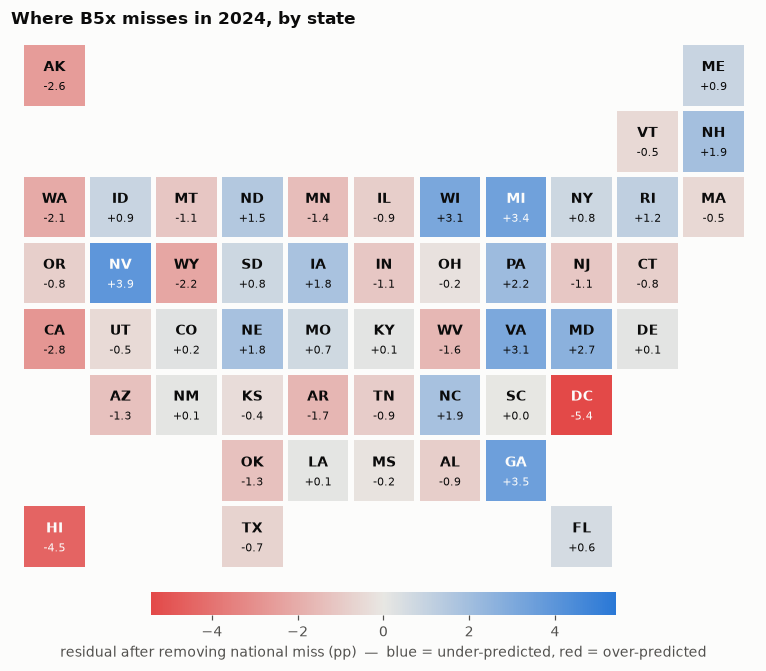

In [70]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
TILE = {"AK":(0,0),"ME":(0,10),"VT":(1,9),"NH":(1,10),
 "WA":(2,0),"ID":(2,1),"MT":(2,2),"ND":(2,3),"MN":(2,4),"IL":(2,5),"WI":(2,6),"MI":(2,7),
 "NY":(2,8),"RI":(2,9),"MA":(2,10),
 "OR":(3,0),"NV":(3,1),"WY":(3,2),"SD":(3,3),"IA":(3,4),"IN":(3,5),"OH":(3,6),"PA":(3,7),
 "NJ":(3,8),"CT":(3,9),
 "CA":(4,0),"UT":(4,1),"CO":(4,2),"NE":(4,3),"MO":(4,4),"KY":(4,5),"WV":(4,6),"VA":(4,7),
 "MD":(4,8),"DE":(4,9),
 "AZ":(5,1),"NM":(5,2),"KS":(5,3),"AR":(5,4),"TN":(5,5),"NC":(5,6),"SC":(5,7),"DC":(5,8),
 "OK":(6,3),"LA":(6,4),"MS":(6,5),"AL":(6,6),"GA":(6,7),
 "HI":(7,0),"TX":(7,3),"FL":(7,8)}
assert len(TILE) == 51 and len(set(TILE.values())) == 51

div = LinearSegmentedColormap.from_list("div", [RED, "#e8e7e3", BLUE])
res24 = oos[oos.year == 2024].set_index("abbr")
resid = res24.turnout - res24.B5x
resid = resid - resid.mean()                               # de-biased: shape only
lim = np.abs(resid).max()
norm = TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim)

fig, ax = plt.subplots(figsize=(10, 6.2))
for s, (r_, c_) in TILE.items():
    val = resid[s]
    ax.add_patch(plt.Rectangle((c_, -r_), 0.92, 0.92, color=div(norm(val)), lw=0))
    txt = INK if abs(val) < lim * 0.6 else SURF
    ax.text(c_ + .46, -r_ + .58, s, ha="center", va="center", fontsize=9,
            fontweight="semibold", color=txt)
    ax.text(c_ + .46, -r_ + .28, f"{val:+.1f}", ha="center", va="center", fontsize=7, color=txt)
ax.set_xlim(-.2, 11.1); ax.set_ylim(-7.2, 1.1); ax.set_aspect("equal"); ax.axis("off")
sm = plt.cm.ScalarMappable(cmap=div, norm=norm)
cb = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=.04, pad=.02, shrink=.5)
cb.set_label("residual after removing national miss (pp)  —  blue = under-predicted, red = over-predicted",
             color=INK2, fontsize=9)
cb.outline.set_visible(False)
ax.set_title("Where B5x misses in 2024, by state", loc="left")
plt.tight_layout(); plt.show()

### 5.8
Side-by-side comparison of the two factor rankings.

                std_coef_|t|  drop_one_dDeb  rank_coef  rank_drop
turnout_prev          10.412          1.271          1          1
cand_v2                2.768          0.083          2          2
margin_prev            1.154          0.067          3          3
access_index           0.527         -0.033          4          6
salience_index         0.498         -0.023          5          5
friction_index         0.241         -0.008          6          4


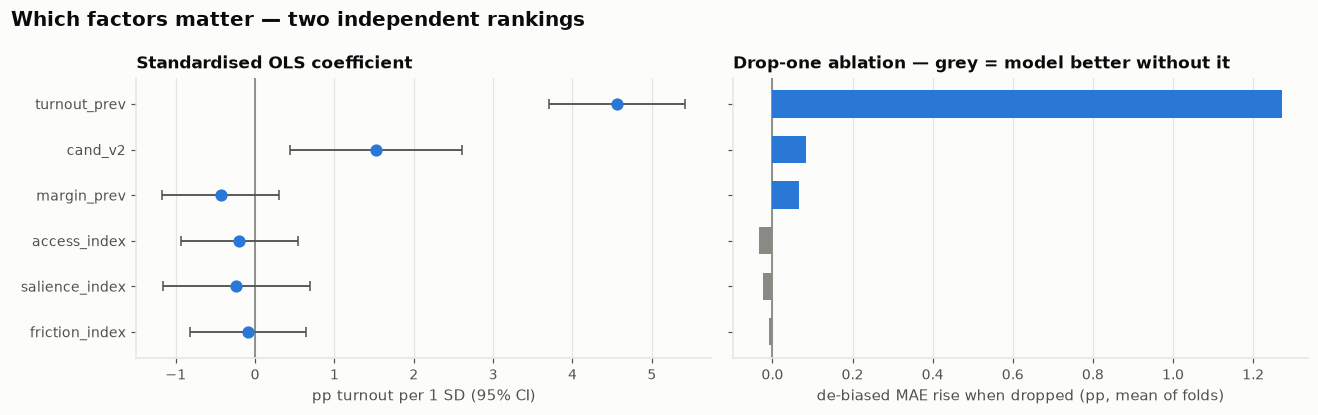

In [71]:
imp_cmp = pd.DataFrame({
    "std_coef_|t|":   coefs.t.abs(),
    "drop_one_dDeb":  abl["mean_dDebiased"],
}).reindex(ALL_F)
imp_cmp["rank_coef"] = imp_cmp["std_coef_|t|"].rank(ascending=False).astype(int)
imp_cmp["rank_drop"] = imp_cmp["drop_one_dDeb"].rank(ascending=False).astype(int)
print(imp_cmp.sort_values("rank_coef").round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
order_i = imp_cmp.sort_values("rank_coef", ascending=False).index
c_ = coefs.loc[order_i]
axes[0].errorbar(c_.coef, range(len(c_)), xerr=1.96 * c_.se, fmt="o", color=BLUE,
                 ecolor=INK2, elinewidth=1.2, capsize=3, ms=7, zorder=3)
axes[0].axvline(0, color=MUTED, lw=1.2, zorder=2)
axes[0].set_yticks(range(len(c_)), order_i)
axes[0].set_xlabel("pp turnout per 1 SD (95% CI)")
axes[0].set_title("Standardised OLS coefficient", loc="left")
clean(axes[0], grid_axis="x")

d_ = imp_cmp.loc[order_i, "drop_one_dDeb"]
axes[1].barh(range(len(d_)), d_.values, height=.6,
             color=[BLUE if x > 0 else MUTED for x in d_.values], zorder=3)
axes[1].axvline(0, color=MUTED, lw=1.2, zorder=2)
axes[1].set_xlabel("de-biased MAE rise when dropped (pp, mean of folds)")
axes[1].set_title("Drop-one ablation — grey = model better without it", loc="left")
clean(axes[1], grid_axis="x")
fig.suptitle("Which factors matter — two independent rankings",
             x=0.005, ha="left", fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

# 6. Error analysis in real numbers
How far the predictions land from the actual vote counts, why, and what else the accuracy can be measured with.

### 6.1
Converts the 2024 predictions from percentage points into ballots, using each state's voting-eligible population.

In [72]:
# === 7.1  Actual vs predicted in VOTES, not just percentage points ==========
def read_vep_counts(path, year):
    d = pd.read_csv(path)
    d.columns = [c.strip().upper() for c in d.columns]
    d["state"]   = d.STATE.astype(str).str.strip().str.replace(r"\*+$", "", regex=True)
    d["vep"]     = num(d.VEP)
    d["ballots"] = num(d.TOTAL_BALLOTS_COUNTED)
    d["year"]    = year
    return d.loc[d.state.isin(STATES), ["state", "year", "vep", "ballots"]]

counts = pd.concat([read_vep_counts(PE / f, y) for y, f in PRES_FILES.items()],
                   ignore_index=True)

PICK_COLS = ["turnout_prev", "cand_v2"]          # B5x = current best model
tr_v = model_df[model_df.year <  2024]
te_v = model_df[model_df.year == 2024].merge(counts, on=["state", "year"], how="left").copy()
te_v["pred"] = predict(fit_ols(tr_v[PICK_COLS].values, tr_v.turnout.values),
                       te_v[PICK_COLS].values)

te_v["err_pp"]     = te_v.turnout - te_v.pred            # + = model UNDER-predicted
te_v["pred_votes"] = te_v.pred / 100 * te_v.vep
te_v["err_votes"]  = te_v.ballots - te_v.pred_votes
te_v["err_pct"]    = 100 * te_v.err_votes / te_v.ballots # error as % of ballots actually cast

print(te_v[["state", "turnout", "pred", "err_pp",
            "ballots", "pred_votes", "err_votes", "err_pct"]]
        .sort_values("err_pp").round(2).to_string(index=False))

print(f"\nmedian |error| : {te_v.err_pp.abs().median():.2f} pp"
      f" = {te_v.err_votes.abs().median():,.0f} votes"
      f" = {te_v.err_pct.abs().median():.1f}% of ballots cast")
print(f"within 1pp {(te_v.err_pp.abs()<=1).mean():.0%} | "
      f"2pp {(te_v.err_pp.abs()<=2).mean():.0%} | "
      f"3pp {(te_v.err_pp.abs()<=3).mean():.0%} of the 51 jurisdictions")
print(f"national : actual {te_v.ballots.sum():,.0f} ballots"
      f"  vs predicted {te_v.pred_votes.sum():,.0f}"
      f"  ({100*(te_v.pred_votes.sum()/te_v.ballots.sum()-1):+.1f}%)")
print("worst 3 by votes: " + ", ".join(
      f"{r.state} {r.err_votes:+,.0f}"
      for r in te_v.reindex(te_v.err_votes.abs().nlargest(3).index).itertuples()))

               state  turnout  pred  err_pp    ballots  pred_votes   err_votes  err_pct
District of Columbia    64.94 72.07   -7.13   328871.0   364990.54   -36119.54   -10.98
              Hawaii    50.26 56.43   -6.17   522236.0   586257.10   -64021.10   -12.26
          California    62.26 66.74   -4.48 16140044.0 17302029.58 -1161985.58    -7.20
              Alaska    63.55 67.84   -4.29   340981.0   363991.17   -23010.17    -6.75
             Wyoming    61.23 65.16   -3.93   271123.0   288529.63   -17406.63    -6.42
          Washington    70.23 74.04   -3.81  3961569.0  4176588.22  -215019.22    -5.43
            Arkansas    54.06 57.44   -3.38  1190172.0  1264608.76   -74436.76    -6.25
       West Virginia    55.56 58.88   -3.32   770587.0   816736.21   -46149.21    -5.99
           Minnesota    76.50 79.63   -3.13  3272414.0  3406240.72  -133826.72    -4.09
             Arizona    63.88 66.90   -3.02  3428011.0  3590043.06  -162032.06    -4.73
            Oklahoma    53.46 56

### 6.2
The same 2024 residuals plotted on both scales side by side.

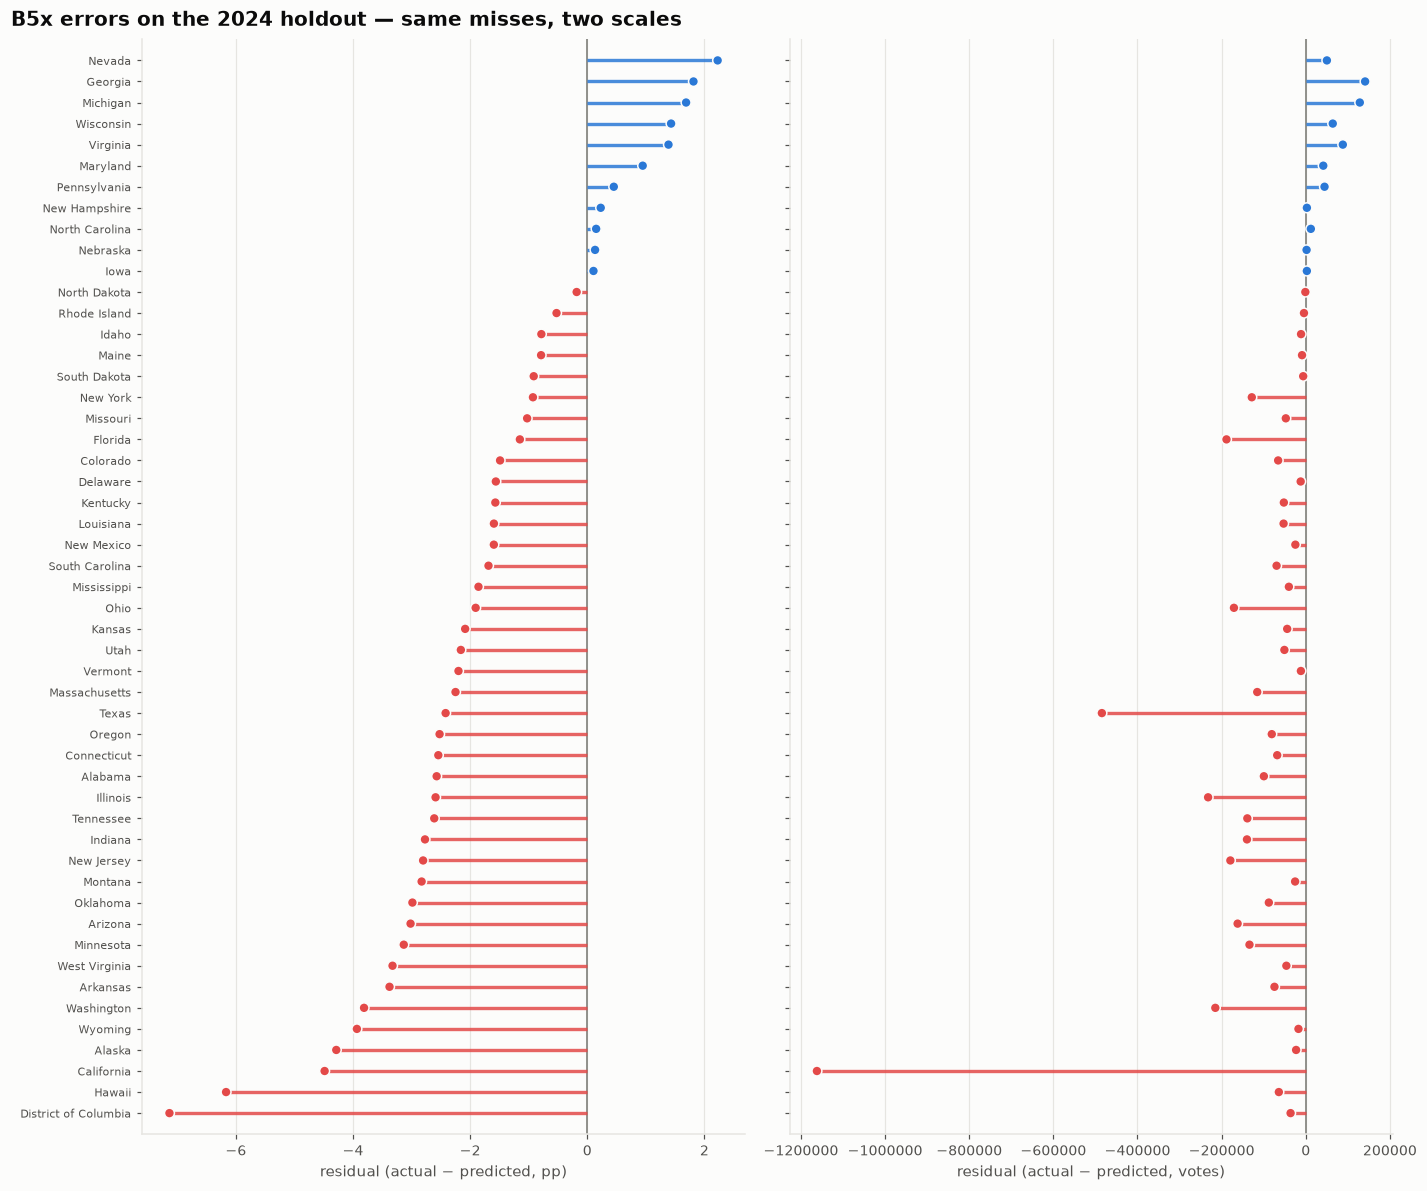

In [73]:
d = te_v.sort_values("err_pp")
fig, axes = plt.subplots(1, 2, figsize=(13, 11), sharey=True)
for ax, (col, lab) in zip(axes, [("err_pp",    "residual (actual − predicted, pp)"),
                                 ("err_votes", "residual (actual − predicted, votes)")]):
    c = np.where(d[col] >= 0, BLUE, RED)
    ax.hlines(range(len(d)), 0, d[col], color=c, lw=2.2, alpha=.85, zorder=3)
    ax.scatter(d[col], range(len(d)), s=42, color=c, edgecolor=SURF, lw=1, zorder=4)
    ax.axvline(0, color=MUTED, lw=1.2, zorder=2)
    ax.set_xlabel(lab); clean(ax, grid_axis="x")
axes[0].set_yticks(range(len(d)), d.state, fontsize=7.5); axes[0].set_ylim(-1, len(d))
axes[1].ticklabel_format(axis="x", style="plain")
fig.suptitle("B5x errors on the 2024 holdout — same misses, two scales",
             x=0.005, ha="left", fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

### 6.3
What the 2024 errors correlate with, and which states the model misses most in each direction.

In [74]:
# === 7.2  Why the 2024 errors look the way they do ==========================
te_v["swing_from_2020"] = te_v.turnout - te_v.turnout_prev
drivers = ["turnout_prev", "cand_v2", "margin_prev", "swing_from_2020"]
print("correlation of the 2024 residual with:")
print(te_v[["err_pp"] + drivers].corr()["err_pp"].drop("err_pp").round(3).to_string())

agg = dict(n="size", mean_err="mean", mae=lambda s: s.abs().mean())
print("\nmean residual by battleground status (prev margin < 5pp):")
print(te_v.groupby("battleground").err_pp.agg(**agg).round(3).to_string())
print("\nmean residual by region:")
print(te_v.groupby("region").err_pp.agg(**agg).round(3).to_string())
print("\nmost under-predicted (model too low):")
print(te_v.nlargest(6, "err_pp")[["state", "err_pp", "err_votes", "battleground"]]
        .round(2).to_string(index=False))
print("\nmost over-predicted (model too high):")
print(te_v.nsmallest(6, "err_pp")[["state", "err_pp", "err_votes", "battleground"]]
        .round(2).to_string(index=False))

correlation of the 2024 residual with:
turnout_prev       0.260
cand_v2           -0.004
margin_prev       -0.579
swing_from_2020    0.836

mean residual by battleground status (prev margin < 5pp):
               n  mean_err    mae
battleground                     
0             43    -2.107  2.237
1              8     0.449  1.491

mean residual by region:
            n  mean_err    mae
region                        
Midwest    12    -0.937  1.497
Northeast   9    -1.261  1.413
South      17    -1.738  2.243
West       13    -2.681  3.023

most under-predicted (model too low):
    state  err_pp  err_votes  battleground
   Nevada    2.23   50171.44             1
  Georgia    1.81  141024.56             1
 Michigan    1.69  128403.77             1
Wisconsin    1.43   64112.37             1
 Virginia    1.39   88029.03             0
 Maryland    0.95   41571.25             0

most over-predicted (model too high):
               state  err_pp   err_votes  battleground
District of Columbia

### 6.4
Extra accuracy measures - MAPE, Spearman rank correlation, within-tolerance hit rates and skill against the naive baseline.

In [75]:
# === 7.3  Extra metrics =====================================================
from scipy.stats import spearmanr

def scores2(y_true, y_pred):
    e  = y_true - y_pred
    ss = ((y_true - y_true.mean()) ** 2).sum()
    return dict(MAE          = np.abs(e).mean(),
                RMSE         = np.sqrt((e ** 2).mean()),
                MAPE         = 100 * np.abs(e / y_true).mean(),     # % of turnout level
                R2           = 1 - (e ** 2).sum() / ss,
                bias         = e.mean(),                            # level error
                debiased_MAE = np.abs(e - e.mean()).mean(),         # cross-state ranking error
                spearman     = spearmanr(y_true, y_pred).statistic, # does it rank states right?
                within_1pp   = (np.abs(e) <= 1).mean(),
                within_2pp   = (np.abs(e) <= 2).mean(),
                max_abs_err  = np.abs(e).max())

MODELS7 = {**MODELS, "B5x + cand v2": ["turnout_prev", "cand_v2"]}
mae_b0  = np.abs(te_v.turnout.values - tr_v.turnout.mean()).mean()   # naive-mean reference

rows = []
for name, cols in MODELS7.items():
    p = (np.full(len(te_v), tr_v.turnout.mean()) if not cols
         else predict(fit_ols(tr_v[cols].values, tr_v.turnout.values), te_v[cols].values))
    s = scores2(te_v.turnout.values, p)
    s["skill_vs_B0"] = 1 - s["MAE"] / mae_b0        # share of the naive error removed
    rows.append(dict(model=name, **s))
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

                                MAE   RMSE   MAPE     R2   bias  debiased_MAE  spearman  within_1pp  within_2pp  max_abs_err  skill_vs_B0
model                                                                                                                                    
B0  national mean             5.150  6.420  7.817 -0.132  2.189         4.859       NaN       0.176       0.314       13.592        0.000
B1  turnout_prev              2.507  2.979  4.018  0.756 -2.179         1.632     0.940       0.216       0.353        7.112        0.513
B2  + friction                2.511  3.031  4.020  0.748 -2.182         1.703     0.934       0.235       0.373        7.669        0.512
B3  + salience                2.510  2.988  4.014  0.755 -2.127         1.688     0.929       0.216       0.392        6.829        0.513
B4  + access                  2.516  2.994  4.032  0.754 -2.181         1.649     0.938       0.216       0.353        7.178        0.511
B5  + candidate               2.15

C:\Users\Nicolas\AppData\Local\Temp\ipykernel_5724\2938106531.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman     = spearmanr(y_true, y_pred).statistic, # does it rank states right?
